# SocialMediaMind

## Interpretable, calibrated and uncertainty-aware detection of mental-health signals in social-media text

Interpretable NLP Classification of Mental-Health-Related Social Media Text
SocialMediaMind is an applied machine learning project that investigates how effectively natural language processing can classify mental-health-related categories in social media text.
The project uses TF-IDF representations and classical machine learning models to predict dataset-provided labels from text. It emphasizes data quality, leakage-aware evaluation, model interpretability, probability calibration, and prediction uncertainty.

**Problem definition**
| Component | Description |
|---|---|
| Input | `statement`: social media text |
| Target | `status`: one of seven dataset-provided categories |
| Task | Multiclass text classification |
| Primary selection metric | Macro-F1 |
| Models | Majority-class baseline, Logistic Regression, and other TF-IDF classifiers |
| Evaluation | Stratified splits, cross-validation, held-out test metrics, and bootstrap confidence intervals |
| Interpretability | Class-specific feature coefficients and error analysis |
| Reliability | Temperature scaling and class-conditional conformal prediction sets |

> ### ⚠️ **Responsible use**
> > ### Responsible use and crisis support
>
> SocialMediaMind is an exploratory research and portfolio project. It is
> **not a clinical diagnostic, screening, or crisis-triage tool**. Its
> predictions must not be used to make decisions about individuals.
>
> If you or someone you know is experiencing emotional distress or having
> thoughts of suicide, confidential support is available:
>
> - **United States:** Call or text **988**, or visit the
>   [988 Suicide & Crisis Lifeline](https://988lifeline.org/).
>
> - **Canada:** Call or text **9-8-8** for the
>   [9-8-8 Suicide Crisis Helpline](https://988.ca/).
>
> - **Europe:** Crisis and emotional-support services vary by country.
>   Visit [Find A Helpline](https://findahelpline.com/) to locate support
>   in your country. In the European Union, call **112** for an emergency.
>   The number **116 123** provides emotional support in some EU countries;
>   availability varies. In the United Kingdom and Ireland, you can contact
>   [Samaritans](https://www.samaritans.org/) free of charge at **116 123**.
>
> If someone is in immediate danger, contact local emergency services.
>
> **Important:** The categories in this dataset are not verified clinical
> diagnoses. Model predictions should never replace professional assessment
> or be interpreted as evidence that an individual has a mental-health
> condition.

## 0. Research questions

* **RQ1 (association).** Do simple, interpretable stylometric properties of a post differ across categories? Examples include length, lexical diversity, first-person pronouns and absolutist words. How large are the differences, rather than just whether they are "significant"?
* **RQ2 (prediction).** How much does modelling the actual *words* add over a majority baseline and over stylometry alone, measured by macro-F1 on unseen, de-duplicated posts?
* **RQ3 (reliability).** Are the model's probabilities calibrated? Can we produce prediction **sets** with a guaranteed error rate, including for the rare, high-stakes classes?
* **RQ4 (explanation and failure modes).** Which features drive predictions, which categories are confused with each other, and where does the model fail?
* **RQ5 (structure).** Without labels, does the language organise into stable topical clusters, and how do those relate to the labels?

## 1. Environment and configuration

In [1]:
#@title Setup: run this first (no GitHub or Kaggle login needed)
# Makes the `socialmediamind` helper package importable, in this order:
#   1. the repository's src/ folder, if this notebook is inside a clone of the repo
#   2. otherwise the copy embedded at the bottom of this cell (gzipped + base64,
#      SHA-256 verified). It is preferred over any pip-installed version because it
#      is guaranteed to match this exact notebook. It is generated from src/ by scripts/build_notebook.py,
#      and tests/test_notebook_sync.py checks it is identical to src/.
import base64, hashlib, importlib.util, io, os, subprocess, sys, tarfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# Third-party libraries: install only what is missing (Colab already has all of them).
REQUIRED = {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy", "sklearn": "scikit-learn",
            "xgboost": "xgboost", "shap": "shap", "matplotlib": "matplotlib", "joblib": "joblib",
            "kagglehub": "kagglehub", "jinja2": "jinja2"}
missing = [pip_name for mod, pip_name in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)


def _setup_package():
    for root in (Path.cwd(), Path.cwd().parent):
        if (root / "src" / "socialmediamind" / "__init__.py").exists():
            sys.path.insert(0, str(root / "src"))
            return root, "repository src/"
    blob = base64.b64decode(EMBEDDED_PACKAGE)
    if hashlib.sha256(blob).hexdigest() != EMBEDDED_SHA256:
        raise RuntimeError("Embedded package is corrupted; re-download the notebook.")
    target = Path.cwd() / "_smm_embedded"
    with tarfile.open(fileobj=io.BytesIO(blob), mode="r:gz") as tar:
        try:
            tar.extractall(target, filter="data")
        except TypeError:  # Python < 3.10.12 has no extraction filters
            tar.extractall(target)
    sys.path.insert(0, str(target))
    for name in [m for m in sys.modules if m == "socialmediamind" or m.startswith("socialmediamind.")]:
        del sys.modules[name]  # never mix with a previously imported/installed version
    return Path.cwd(), "embedded copy"


EMBEDDED_SHA256 = "bffa7ab98a696f059fa478a623778a72362ea689b7e8f60d6707277fb3b8f878"
EMBEDDED_PACKAGE = "..."

ROOT, PKG_SOURCE = _setup_package()
import socialmediamind  # noqa: E402

print(f"socialmediamind {socialmediamind.__version__} loaded from {PKG_SOURCE} | outputs -> {ROOT}")

socialmediamind 0.2.0 loaded from embedded copy | outputs -> /content


In [2]:
import json, math, platform, random, time, warnings
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy, sklearn, xgboost, shap

from scipy.stats import loguniform
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    adjusted_rand_score, classification_report, confusion_matrix, f1_score,
    normalized_mutual_info_score, silhouette_score,
)
from sklearn.base import clone
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_val_predict, cross_validate, train_test_split,
)
from sklearn.preprocessing import Normalizer

from socialmediamind import LABEL_ORDER
from socialmediamind.calibration import TemperatureScaler
from socialmediamind.conformal import SplitConformalClassifier, coverage_report
from socialmediamind.data import (
    LABEL_COL, TEXT_COL, assert_no_overlap, clean_and_deduplicate, load_raw,
    make_splits, normalise_for_dedup, standardise_schema,
)
from socialmediamind.evaluation import bootstrap_ci, classification_metrics, reliability_table
from socialmediamind.features import STYLOMETRIC_FEATURES, stylometric_frame
from socialmediamind.inference import SocialMediaMindModel
from socialmediamind.models import explain_text, model_ladder, top_terms_per_class
from socialmediamind.noise import estimated_noise_rate, find_label_issues
from socialmediamind.stats import cliffs_vs_reference, kruskal_by_group

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------- configuration ----------------
RANDOM_STATE = 42
FAST_MODE = os.environ.get("SMM_FAST", "0") == "1"   # quick smoke run (CI / synthetic data)
SHOW_TEXT_EXAMPLES = False                           # keep sensitive post text out of saved outputs
CV_FOLDS = 3 if FAST_MODE else 5
SEARCH_ITER = 3 if FAST_MODE else 12
TUNE_SAMPLE = 4_000 if FAST_MODE else 20_000         # subsample for hyper-parameter search speed
N_BOOT = 200 if FAST_MODE else 1_000
ALPHA = 0.10                                         # conformal miscoverage -> 90% sets
CLUSTER_SAMPLE = 3_000 if FAST_MODE else 15_000
# Transformer baseline: "auto" = run only when a CUDA GPU is available (Colab: Runtime → Change runtime type → GPU)
SMM_TRANSFORMER = os.environ.get("SMM_TRANSFORMER", "auto")
TRANSFORMER_NAME = "distilroberta-base"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

REPORT_DIR, MODEL_DIR, FIG_DIR = ROOT / "reports", ROOT / "models", ROOT / "reports" / "figures"
for p in (REPORT_DIR, MODEL_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

# Validated categorical palette (fixed order -> colour follows the class, never its rank).
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold",
    "axes.prop_cycle": plt.cycler(color=PALETTE),
})

def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

ENV = {
    "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
    "scipy": scipy.__version__, "scikit-learn": sklearn.__version__,
    "xgboost": xgboost.__version__, "shap": shap.__version__,
    "fast_mode": FAST_MODE, "random_state": RANDOM_STATE,
}
pd.Series(ENV, name="value").to_frame()

,value
python,3.13.16
numpy,2.1.3
pandas,2.2.3
scipy,1.16.3
scikit-learn,1.6.1
xgboost,3.4.1
shap,0.52.0
fast_mode,False
random_state,42


## 2. Data Acquisition and Provenance

### Data Source

This project uses the **[Sentiment Analysis for Mental Health](https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health)** dataset, published on Kaggle by `suchintikasarkar`.

The dataset compiles social-media text from multiple public sources, including Reddit and Twitter, and associates each statement with one of seven mental-health-related categories.

| Property | Description |
|---|---|
| Dataset name | Sentiment Analysis for Mental Health |
| Publisher | `suchintikasarkar` |
| Source | [Kaggle dataset page](https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health) |
| Data format | CSV |
| Input feature | `statement` |
| Target variable | `status` |
| Prediction task | Multiclass text classification |
| Number of classes | 7 |

The dataset version inspected for this project contains **53,043 rows before cleaning**. The number of observations used for model development may be lower after removing missing or empty statements, resolving conflicting labels, and deduplicating the data.

### Understanding the Labels

The dataset's labels must be interpreted in the context of their original data sources.

- **Labels are not clinical diagnoses.** They reflect the labeling and collection procedures of the source datasets and may be associated with a particular community or collection context.
- **Label noise is expected.** A statement collected from a mental-health-related community may contain general discussion, supportive advice, or references to someone else's experience rather than a first-person disclosure.
- **Source-related bias is possible.** Because the dataset combines material from multiple sources, differences in language, platform, topic, and collection practices may influence predictions.
- **Generalization is uncertain.** Strong performance on this dataset does not establish that the model will perform equally well on unseen platforms, populations, or real-world mental-health data.

These limitations are central to the project. The objective is to evaluate text-classification methods on the available dataset, not to determine an individual's mental-health condition.

### Data Access

The notebook supports the following data-loading sequence:

1. **Explicit path:** Load the dataset from the location specified by the `SMM_DATA_PATH` environment variable.
2. **Local file:** Look for `Combined Data.csv` beside the notebook or in the `data/` directory.
3. **Public download:** Attempt to retrieve the dataset using `kagglehub`.
4. **Colab fallback:** If the download fails in Google Colab, prompt the user to upload the CSV downloaded from the original Kaggle dataset page.

The public-download option is intended to avoid requiring a Kaggle login when the dataset is accessible anonymously. If the download is unavailable in the current environment, the local-file or upload options can be used instead.

### Data Preparation and Reproducibility

Before training, the notebook validates the dataset schema and performs data-quality checks. These include handling missing and empty statements, identifying duplicate texts and conflicting labels, and removing the exported row-index column when present.

The cleaned data is then divided into training, calibration, and test sets. Duplicate-text overlap is checked to reduce the risk of information leakage between these sets.

**Data attribution:** The dataset is hosted on Kaggle. Users should consult the [original dataset page](https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health) for licensing, usage conditions, and any applicable attribution requirements.

In [3]:
# 2. DATA ACQUISITION AND SCHEMA STANDARDIZATION

df_raw = load_raw()

print("Raw shape:", df_raw.shape)
print("Raw columns:", list(df_raw.columns))

# Standardize column names and remove the exported row-index column
df = standardise_schema(df_raw)

# Preview one record per available class
preview = (
    df.dropna(subset=[TEXT_COL, LABEL_COL])
      .groupby(LABEL_COL, group_keys=False)
      .sample(n=1, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)

if SHOW_TEXT_EXAMPLES:
    preview[TEXT_COL] = (
        preview[TEXT_COL]
        .astype("string")
        .str.slice(0, 60)
        .fillna("[missing]")
        + "…"
    )
else:
    preview[TEXT_COL] = "[hidden]"

display(preview)

100%|██████████| 11.1M/11.1M [00:00<00:00, 12.4MB/s]

Extracting files...


[data] loading /root/.cache/kagglehub/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/versions/1/Combined Data.csv
Raw shape: (53043, 3)
Raw columns: ['Unnamed: 0', 'statement', 'status']


,text,label
0,[hidden],Anxiety
1,[hidden],Bipolar
2,[hidden],Depression
3,[hidden],Normal
4,[hidden],Personality disorder
5,[hidden],Stress
6,[hidden],Suicidal


> **Why we remove `Unnamed: 0`:**
>
> `Unnamed: 0` is an exported row-index column, not a meaningful feature for text classification. In this dataset version, the original records are ordered by label, making the row index potentially predictive of the target for the wrong reason.
>
> Retaining this column could introduce **target leakage**, allowing a model to exploit the dataset's ordering rather than learn meaningful patterns in the text. It must therefore be excluded from both the input features and the target construction.
>
> The actual prediction task is to classify `text` into its corresponding `label` using the textual content, not the record's position in the dataset.

## 3. Data audit

,dtype,missing_n,missing_pct,unique_n
text,object,362,0.682,51073
label,object,0,0.000,7


Valid non-empty text records: 52,680
Rows sharing normalized text with another row: 6.00%
Distinct normalized texts appearing more than once: 1,451
Distinct normalized texts with conflicting labels: 30


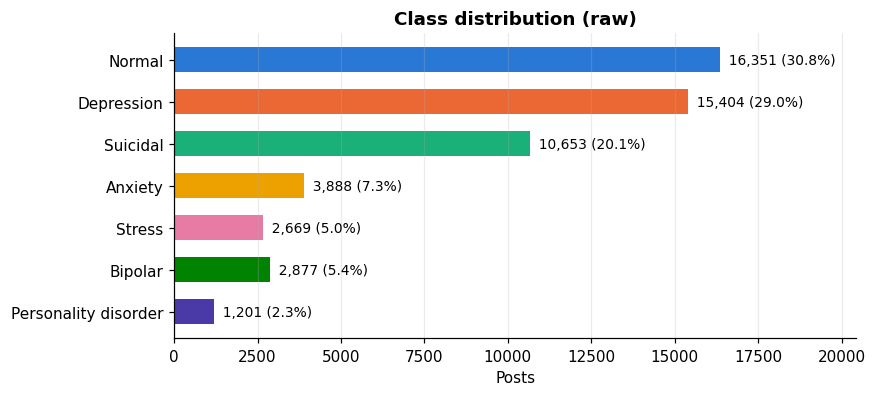

In [6]:
# 3. DATA AUDIT

# Basic schema and data-quality summary
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(3),
    "unique_n": df.nunique(),
})

display(audit)


# Audit repeated normalized text and conflicting labels
audit_text = df.loc[
    df[TEXT_COL].notna(),
    [TEXT_COL, LABEL_COL]
].copy()

# Normalize text for duplicate detection
audit_text["_key"] = (
    audit_text[TEXT_COL]
    .map(normalise_for_dedup)
    .astype("string")
    .str.strip()
)

# Exclude missing or empty normalized text
valid_key_mask = (
    audit_text["_key"].notna()
    & audit_text["_key"].fillna("").ne("")
)

audit_text = audit_text.loc[valid_key_mask].copy()

# Identify rows belonging to repeated normalized-text groups
duplicate_mask = audit_text["_key"].duplicated(keep=False)

dup_share = (
    duplicate_mask.mean()
    if len(audit_text) > 0
    else 0.0
)

# Count distinct normalized texts that appear more than once
duplicate_groups = (
    audit_text.loc[duplicate_mask, "_key"].nunique()
)

# Count normalized texts associated with multiple labels
conflicts = (
    audit_text.groupby("_key")[LABEL_COL]
    .nunique()
    .gt(1)
    .sum()
)

print(f"Valid non-empty text records: {len(audit_text):,}")
print(
    f"Rows sharing normalized text with another row: "
    f"{dup_share:.2%}"
)
print(
    f"Distinct normalized texts appearing more than once: "
    f"{duplicate_groups:,}"
)
print(
    f"Distinct normalized texts with conflicting labels: "
    f"{conflicts:,}"
)


# Class distribution
labels_present = (
    [c for c in LABEL_ORDER if c in set(df[LABEL_COL])]
    + sorted(set(df[LABEL_COL]) - set(LABEL_ORDER))
)

COLOR = {
    c: PALETTE[i % len(PALETTE)]
    for i, c in enumerate(labels_present)
}

counts = df[LABEL_COL].value_counts().reindex(labels_present)

fig, ax = plt.subplots(figsize=(8, 3.6))

ax.barh(
    counts.index[::-1],
    counts.values[::-1],
    color=[COLOR[c] for c in counts.index[::-1]],
    height=0.6,
)

for y, v in enumerate(counts.values[::-1]):
    ax.text(
        v,
        y,
        f"  {v:,} ({v / counts.sum():.1%})",
        va="center",
        fontsize=9,
    )

ax.set_title("Class distribution (raw)")
ax.set_xlabel("Posts")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, counts.max() * 1.25)

savefig("class_distribution")
plt.show()

The classes are **imbalanced**: the largest class (`Normal`) contains 16,351 records (30.8%), while the smallest class (`Personality disorder`) contains 1,201 records (2.3%). The largest class is approximately **13.6 times the size of the smallest**.

Accuracy alone may conceal poor performance on minority classes. Therefore, **macro-F1 is the primary model-selection metric**, with balanced accuracy, weighted-F1, and per-class precision and recall providing additional context.

## 4. Cleaning, Deduplication, and Leakage-Safe Splits

Data cleaning and splitting must be performed in the correct order to reduce data leakage and ensure a reliable evaluation.

### Data preparation sequence

1. **Remove missing and empty text.** Exclude records whose statements are missing or become empty after normalization.
2. **Resolve conflicting labels.** Identify normalized text that appears with multiple labels and exclude all records belonging to these conflicting groups. Such conflicts may reflect ambiguous statements or inconsistencies in the original annotations.
3. **Deduplicate the remaining records.** Normalize text consistently, including case, punctuation, and URLs, then retain one representative record per normalized text.
4. **Create stratified data splits.** Divide the cleaned dataset into training (70%), calibration (15%), and test (15%) sets, preserving class proportions as closely as possible.

### Purpose of each split

| Split | Proportion | Purpose |
|---|---:|---|
| Training | 70% | Fit models, perform cross-validation, and select hyperparameters. |
| Calibration | 15% | Calibrate predicted probabilities and determine conformal prediction thresholds. This set is reserved for calibration, not model fitting or selection. |
| Test | 15% | Evaluate the final selected model on previously unseen data. Keep this set untouched until the final evaluation. |

### Leakage prevention

Deduplication must occur **before splitting** so that identical normalized statements cannot appear in multiple subsets.

The notebook also checks for text overlap between the training, calibration, and test sets. This helps prevent artificially optimistic evaluation results caused by repeated statements.

All model selection and hyperparameter tuning must be completed using the training set. The calibration set is reserved for probability calibration and conformal prediction, while the test set is reserved for final performance evaluation.

In [7]:
# 4. CLEANING, DEDUPLICATION, AND LEAKAGE-SAFE SPLITS

df_clean, cleaning = clean_and_deduplicate(df)

display(
    pd.Series(cleaning.to_dict(), name="count")
    .drop("notes")
    .to_frame()
)

# Create training, calibration, and test splits
splits = make_splits(
    df_clean,
    test_size=0.15,
    cal_size=0.15,
    random_state=RANDOM_STATE,
)

# Check that normalized text does not leak across splits
assert_no_overlap(
    splits.X_train,
    splits.X_cal,
    splits.X_test,
)

print("Split sizes:", splits.sizes(), "| overlap check passed ✓")

X_train, y_train = splits.X_train, splits.y_train
X_cal, y_cal = splits.X_cal, splits.y_cal
X_test, y_test = splits.X_test, splits.y_test

# Display class proportions across splits
split_distribution = pd.DataFrame({
    "train": y_train.value_counts(normalize=True),
    "calibration": y_cal.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True),
}).reindex(labels_present)

display(split_distribution.style.format("{:.1%}"))

# Validate split integrity
assert len(X_train) == len(y_train)
assert len(X_cal) == len(y_cal)
assert len(X_test) == len(y_test)

assert (
    len(X_train) + len(X_cal) + len(X_test)
    == len(df_clean)
), "Split sizes do not match the cleaned dataset."

assert set(y_train.unique()) == set(y_cal.unique())
assert set(y_train.unique()) == set(y_test.unique())

print("\nSplit integrity checks passed.")
print(f"Training samples:   {len(X_train):,}")
print(f"Calibration samples: {len(X_cal):,}")
print(f"Test samples:       {len(X_test):,}")
print(f"Number of classes:  {y_train.nunique()}")

,count
n_raw,53043
n_missing_text,362
n_empty_text,1
n_exact_duplicates_removed,1662
n_conflicting_texts,30
n_conflicting_rows_removed,78
n_final,50940


Split sizes: {'train': 35657, 'calibration': 7642, 'test': 7641} | overlap check passed ✓


,train,calibration,test
label,,,
Normal,31.4%,31.4%,31.4%
Depression,29.6%,29.6%,29.6%
Suicidal,20.8%,20.8%,20.8%
Anxiety,7.1%,7.1%,7.1%
Stress,4.5%,4.5%,4.5%
Bipolar,4.9%,4.9%,4.9%
Personality disorder,1.8%,1.8%,1.8%



Split integrity checks passed.
Training samples:   35,657
Calibration samples: 7,642
Test samples:       7,641
Number of classes:  7


### 4.1 Investigating the Effect of Duplicate Leakage

This experiment compares the performance of the same model under two evaluation setups:

- **(A) Naive evaluation:** Randomly split the original dataset before removing duplicates. Identical or near-identical statements may appear in both the training and test sets, allowing the model to benefit from previously seen text.
- **(B) Leakage-aware evaluation:** Use the cleaned, deduplicated dataset and the train/test split established above, ensuring that normalized statements do not overlap across partitions.

Both setups use the same model family and evaluation metric to make the comparison as informative as possible.

**Interpretation:** If the naive evaluation produces better results, this may indicate that duplicate leakage has inflated the apparent performance. However, the difference cannot automatically be attributed entirely to leakage because the datasets may also differ in size, class distribution, and label quality.

This experiment illustrates why duplicate handling and leakage-aware evaluation matter when estimating how well a text classification model generalizes to unseen statements.

In [8]:
# 4.1. DUPLICATE-LEAKAGE DEMONSTRATION
# Compare a naive row-level split with the cleaned, deduplicated split.

# A. Prepare a dataset that retains duplicate rows

naive = df.loc[
    df[TEXT_COL].notna(),
    [TEXT_COL, LABEL_COL]
].copy()

# Remove missing or empty text after normalization.
# Keep duplicate rows intentionally for this demonstration.
naive["_key"] = (
    naive[TEXT_COL]
    .map(normalise_for_dedup)
    .astype("string")
    .str.strip()
)

valid_mask = (
    naive["_key"].notna()
    & naive["_key"].ne("")
)

naive = naive.loc[valid_mask].copy()

# Exclude conflicting-label groups so that this comparison
# focuses on duplicate leakage rather than contradictory labels.
labels_per_key = naive.groupby("_key")[LABEL_COL].nunique()

conflict_keys = labels_per_key[
    labels_per_key > 1
].index

naive = naive.loc[
    ~naive["_key"].isin(conflict_keys)
].copy()

print(f"Naive dataset rows, duplicates retained: {len(naive):,}")
print(f"Conflicting text groups excluded: {len(conflict_keys):,}")


# B. Create a stratified 70/15/15 split

Xn = naive[TEXT_COL]
yn = naive[LABEL_COL]

Xn_tr, Xn_temp, yn_tr, yn_temp = train_test_split(
    Xn,
    yn,
    test_size=0.30,
    stratify=yn,
    random_state=RANDOM_STATE,
)

Xn_cal, Xn_te, yn_cal, yn_te = train_test_split(
    Xn_temp,
    yn_temp,
    test_size=0.50,
    stratify=yn_temp,
    random_state=RANDOM_STATE,
)


# C. Measure duplicate overlap between train and test

train_keys = set(Xn_tr.map(normalise_for_dedup))
test_keys = Xn_te.map(normalise_for_dedup)

leaked = (
    test_keys.isin(train_keys).mean()
    if len(test_keys) > 0
    else 0.0
)


# D. Evaluate the same model configuration twice

probe = model_ladder(
    RANDOM_STATE,
    include_xgb=False,
)["4 Word TF-IDF + LogReg"]

# Naive evaluation: duplicate rows can cross the split.
naive_model = clone(probe)

naive_model.fit(Xn_tr, yn_tr)

pred_naive = naive_model.predict(Xn_te)

f1_naive = f1_score(
    yn_te,
    pred_naive,
    labels=labels_present,
    average="macro",
    zero_division=0,
)

# Clean evaluation: use the existing deduplicated split.
clean_model = clone(probe)

clean_model.fit(X_train, y_train)

pred_clean = clean_model.predict(X_test)

f1_clean = f1_score(
    y_test,
    pred_clean,
    labels=labels_present,
    average="macro",
    zero_division=0,
)


# E. Compare results

leak_demo = pd.DataFrame(
    {
        "train_posts": [
            len(Xn_tr),
            len(X_train),
        ],
        "test_posts": [
            len(Xn_te),
            len(X_test),
        ],
        "test_posts_with_duplicate_in_train": [
            f"{leaked:.1%}",
            "0.0%",
        ],
        "macro_F1": [
            round(f1_naive, 4),
            round(f1_clean, 4),
        ],
    },
    index=[
        "(A) Naive split: duplicates retained",
        "(B) Clean split: deduplicated",
    ],
)

display(leak_demo)

print(
    f"\nMacro-F1 difference (naive - clean): "
    f"{f1_naive - f1_clean:+.4f}"
)

Naive dataset rows, duplicates retained: 52,602
Conflicting text groups excluded: 30


,train_posts,test_posts,test_posts_with_duplicate_in_train,macro_F1
(A) Naive split: duplicates retained,36821,7891,4.6%,0.7666
(B) Clean split: deduplicated,35657,7641,0.0%,0.7445



Macro-F1 difference (naive - clean): +0.0222


The naive evaluation achieved a macro-F1 of 0.7666, compared with
0.7445 for the deduplicated evaluation, a difference of approximately
2.22 percentage points.

In the naive split, 4.6% of test records had normalized text matching
at least one training record. The deduplicated split had no normalized
text overlap across its partitions.

These findings are consistent with duplicate leakage contributing
to overly optimistic performance estimates. However, the observed
difference cannot be attributed exclusively to leakage because the
two evaluations use different datasets and test observations.

The experiment illustrates why duplicate handling and leakage-aware
evaluation are important when estimating how well an NLP model
generalizes to unseen statements.

**Conclusion:** Performance should be evaluated on data that does not
contain duplicate or near-duplicate statements from the training set.
The deduplicated evaluation is therefore the more appropriate estimate
of performance on unseen text for this project.

## 5. RQ1: Do Interpretable Writing-Style Features Differ by Category?

This research question examines whether interpretable **stylometric features**
differ across the dataset's seven text categories. These features describe
aspects of writing style rather than relying solely on learned text
representations.

### Feature Engineering

Twelve stylometric features are extracted from each post. Where appropriate,
counts are normalized by the number of words to reduce the influence of
document length. The feature set includes two measures motivated by prior
research:

- **First-person singular pronouns:** The frequency of terms such as *I*,
  *me*, and *my*. Previous research has associated greater first-person
  singular pronoun use with depressive language (Rude et al., 2004).
- **Absolutist language:** The frequency of terms such as *always*,
  *never*, and *completely*. Research has reported elevated use of
  absolutist language in online discussions associated with anxiety,
  depression, and suicidal ideation (Al-Mosaiwi & Johnstone, 2018).

These associations motivate the features; they do not establish that either
feature can diagnose a mental-health condition or reliably distinguish
individuals by clinical status.

### Statistical Analysis

The analysis uses the **training split only** to avoid using the calibration
or test data during exploratory feature analysis.

Because writing-style measurements may be skewed and may contain outliers,
the following procedures are used:

1. **Kruskal–Wallis tests** assess whether each feature's distribution
   differs across the seven categories.
2. **Epsilon-squared (ε²)** estimates the effect size of each
   Kruskal–Wallis test, helping distinguish the magnitude of a difference
   from its statistical significance.
3. **Cliff's delta (δ)** quantifies the pairwise difference between each
   category and the *Normal* reference category.
4. **Benjamini–Hochberg correction** controls the false-discovery rate
   across the 12 feature-level tests.

With a large sample, even small differences can produce low p-values.
Therefore, effect sizes and the distributions of the features are emphasized
when interpreting the results, rather than statistical significance alone.

### Interpretation and Limitations

The analysis identifies differences in writing-style features between
dataset categories. Such differences may reflect language patterns, source
characteristics, topic differences, annotation practices, or other
confounding factors.

The results should therefore be interpreted as **descriptive associations
within this dataset**, not evidence of causal relationships or clinical
differences between individuals.

,feature,H,p_value,epsilon_sq,q_value_bh,magnitude
0,n_chars,"17,387.88",0.00e+00,0.488,0.00e+00,large
1,n_words,"17,359.94",0.00e+00,0.487,0.00e+00,large
2,type_token_ratio,"16,383.26",0.00e+00,0.459,0.00e+00,large
3,n_sentences,"12,111.40",0.00e+00,0.340,0.00e+00,large
4,first_person_rate,"6,787.01",0.00e+00,0.190,0.00e+00,medium
5,absolutist_rate,"6,280.23",0.00e+00,0.176,0.00e+00,medium
6,punctuation_ratio,"4,079.69",0.00e+00,0.114,0.00e+00,medium
7,uppercase_ratio,"3,381.35",0.00e+00,0.095,0.00e+00,medium
8,question_rate,"2,834.01",0.00e+00,0.079,0.00e+00,small
9,digit_ratio,"2,178.59",0.00e+00,0.061,0.00e+00,small


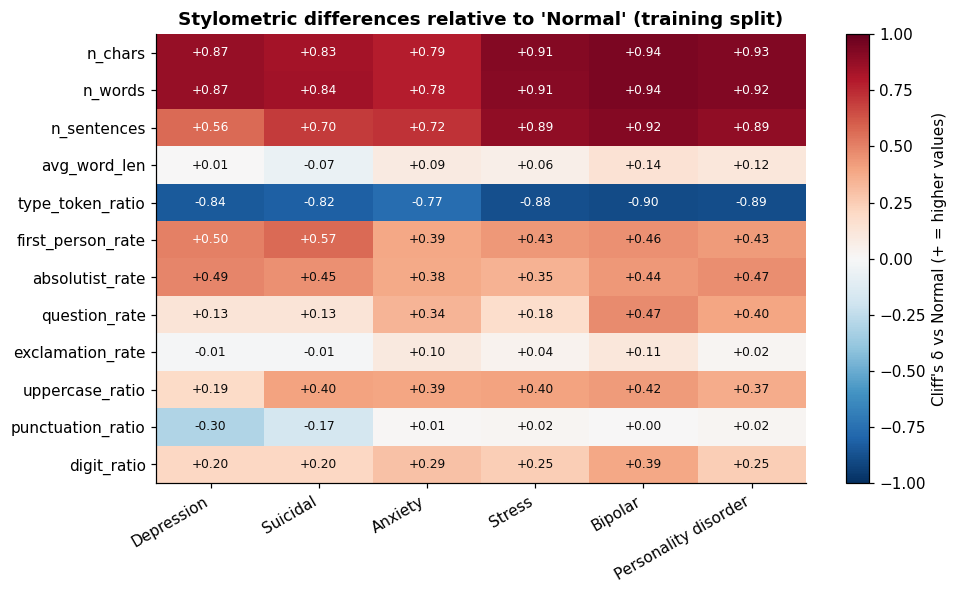

In [9]:
# 5. RQ1: STYLOMETRIC ANALYSIS
# All analyses use the training split only.

# Extract interpretable writing-style features
style_train = stylometric_frame(X_train).reset_index(drop=True)

y_train_array = np.asarray(y_train)
if len(style_train) != len(y_train_array):
    raise ValueError(
        "Feature and label counts differ. Check the alignment of X_train and y_train."
    )

style_train["label"] = y_train_array

missing_features = [
    feature for feature in STYLOMETRIC_FEATURES
    if feature not in style_train.columns
]
if missing_features:
    raise ValueError(f"Missing stylometric features: {missing_features}")

# Omnibus tests across all available categories
kw = kruskal_by_group(
    style_train,
    STYLOMETRIC_FEATURES,
    "label",
)

# Epsilon-squared magnitude bands
# < 0.01: negligible; 0.01–<0.08: small;
# 0.08–<0.26: medium; >= 0.26: large.
kw["magnitude"] = pd.cut(
    kw["epsilon_sq"],
    bins=[-np.inf, 0.01, 0.08, 0.26, np.inf],
    labels=["negligible", "small", "medium", "large"],
    right=False,
)

display(
    kw.style.format({
        "H": "{:,.2f}",
        "p_value": "{:.2e}",
        "q_value_bh": "{:.2e}",
        "epsilon_sq": "{:.3f}",
    })
)

# Compare each category with the Normal reference category
reference = (
    "Normal"
    if "Normal" in labels_present
    else labels_present[0]
)

delta = cliffs_vs_reference(
    style_train,
    STYLOMETRIC_FEATURES,
    "label",
    reference,
)

# Retain available categories and omit the reference column.
# The heatmap assumes features are rows and categories are columns.
plot_columns = [
    category
    for category in labels_present
    if category in delta.columns and category != reference
]
delta_plot = delta.loc[:, plot_columns]

if delta_plot.empty or delta_plot.shape[1] == 0:
    raise ValueError(
        "The Cliff's delta result has no comparison columns. "
        "Check the output orientation of cliffs_vs_reference()."
    )

# Visualize effect direction and magnitude
fig, ax = plt.subplots(figsize=(9, 5.5))

im = ax.imshow(
    delta_plot.to_numpy(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(
    range(delta_plot.shape[1]),
    delta_plot.columns,
    rotation=30,
    ha="right",
)
ax.set_yticks(range(delta_plot.shape[0]), delta_plot.index)

for i in range(delta_plot.shape[0]):
    for j in range(delta_plot.shape[1]):
        value = delta_plot.iat[i, j]
        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:+.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(value) > 0.5 else "#0b0b0b",
            )

ax.grid(False)
fig.colorbar(
    im,
    ax=ax,
    label=f"Cliff's δ vs {reference} (+ = higher values)",
)
ax.set_title(f"Stylometric differences relative to '{reference}' (training split)")

fig.tight_layout()
savefig("cliffs_delta_heatmap")
plt.show()

The Kruskal–Wallis analysis identified statistically significant differences
across the seven categories for all 12 stylometric features after
Benjamini–Hochberg correction.

The largest effect sizes were observed for character count
(ε² = 0.488), word count (ε² = 0.487), type-token ratio
(ε² = 0.459), and sentence count (ε² = 0.340). These results indicate
that text length and lexical diversity account for substantial
differences between category distributions.

First-person pronoun rate (ε² = 0.190) and absolutist-language rate
(ε² = 0.176) showed medium-sized effects under the thresholds used in
this analysis. These findings support examining these interpretable
linguistic features when characterizing differences between the dataset
categories.

The Cliff's delta heatmap compares each category with the Normal
reference group. First-person and absolutist-language rates have
positive effect estimates across all six non-reference categories,
indicating a tendency toward higher values relative to Normal in this
dataset. The magnitude of these differences varies by category.

However, the results should be interpreted cautiously. Statistical
significance does not necessarily imply practical importance, particularly
with a large sample. Furthermore, text length can influence lexical
diversity and the stability of word-normalized rates. Differences may
also reflect source composition, topic, annotation practices, or other
confounding factors.

These findings describe associations within the dataset; they do not
establish causality, clinical differences, or diagnostic validity.

**RQ1 conclusion:** Interpretable writing-style features differ across
the dataset categories, with the strongest observed effects involving
text length and lexical diversity. First-person and absolutist-language
features also show meaningful distributional differences and warrant
further investigation.

## 6. RQ2: The Model Ladder

This research question evaluates whether increasingly expressive text
representations improve multiclass classification performance.

Six model configurations are evaluated using **stratified k-fold
cross-validation on the training split**. The progression begins with
a majority-class baseline, moves through interpretable stylometric
features, and then evaluates word-level and combined word-and-character
TF-IDF representations.

| # | Model | Research purpose |
|---|---|---|
| 0 | Majority-class baseline | Establish a minimum reference point for predictive performance. |
| 1 | Stylometric features + Logistic Regression | Evaluate how much predictive information is captured by the 12 interpretable writing-style features alone. |
| 2 | Stylometric features + XGBoost | Test whether nonlinear relationships and interactions between stylometric features improve performance. |
| 3 | Word TF-IDF + Complement Naive Bayes | Evaluate a conventional text-classification baseline suited to imbalanced classification problems. |
| 4 | Word TF-IDF + Logistic Regression | Evaluate a discriminative linear classifier using word-level features. |
| 5 | Word + character TF-IDF + Logistic Regression | Test whether character-level features improve robustness to spelling variations, morphology, slang, and informal writing. |

### Evaluation Protocol

All candidate models are evaluated using the same stratified cross-validation
procedure on the training split. Stratification aims to preserve class
proportions across folds, which is particularly important because the
dataset contains substantial class imbalance.

**Macro-F1 is the primary evaluation metric** because it gives equal weight
to each class, regardless of its frequency. Balanced accuracy, weighted-F1,
and class-level precision and recall provide additional context.

The majority-class baseline establishes the performance of a classifier
that always predicts the most frequent class. The remaining models are
evaluated against this baseline and against one another.

### Leakage Prevention

Text vectorization must occur **inside each model pipeline**. TF-IDF
vocabularies and inverse-document-frequency statistics are therefore
learned from the training portion of each cross-validation fold rather
than from the complete dataset.

The calibration and test splits remain separate from cross-validation
and model selection. The calibration split is reserved for probability
calibration and conformal prediction, while the test split is reserved
for final evaluation after the model-selection process is complete.

For class imbalance, Logistic Regression uses
`class_weight="balanced"`. XGBoost uses inverse-frequency sample weights.
Any preprocessing, feature selection, or other data-dependent operation
must also be fitted using only the corresponding training fold.

### Model Selection

The final model family is selected using the cross-validation results,
with macro-F1 as the primary criterion and the other metrics used to
assess trade-offs.

A more complex model is not automatically preferable. Performance,
minority-class behavior, computational cost, interpretability, and
suitability for probability calibration should all be considered when
selecting the final candidate.

0 Majority class                   Macro-F1: 0.0682 ± 0.0000  | Balanced accuracy: 0.1429  | Accuracy: 0.3135  | Elapsed: 6.5s
1 Stylometric + LogReg             Macro-F1: 0.3474 ± 0.0051  | Balanced accuracy: 0.3881  | Accuracy: 0.5095  | Elapsed: 45.0s
2 Stylometric + XGBoost            Macro-F1: 0.4201 ± 0.0029  | Balanced accuracy: 0.4720  | Accuracy: 0.5603  | Elapsed: 83.5s
3 Word TF-IDF + ComplementNB       Macro-F1: 0.6183 ± 0.0120  | Balanced accuracy: 0.6067  | Accuracy: 0.7141  | Elapsed: 56.5s
4 Word TF-IDF + LogReg             Macro-F1: 0.7382 ± 0.0089  | Balanced accuracy: 0.7408  | Accuracy: 0.7837  | Elapsed: 198.5s
5 Word+Char TF-IDF + LogReg        Macro-F1: 0.7579 ± 0.0074  | Balanced accuracy: 0.7635  | Accuracy: 0.7980  | Elapsed: 822.1s

Cross-validation results, ranked by macro-F1:


,macro_f1,macro_f1_sd,balanced_acc,balanced_acc_sd,accuracy,accuracy_sd,fit_s_per_fold,total_elapsed_s
model,,,,,,,,
5 Word+Char TF-IDF + LogReg,0.7579,0.0074,0.7635,0.0054,0.7980,0.0050,284.7,822.1
4 Word TF-IDF + LogReg,0.7382,0.0089,0.7408,0.0051,0.7837,0.0063,69.3,198.5
3 Word TF-IDF + ComplementNB,0.6183,0.0120,0.6067,0.0100,0.7141,0.0054,16.9,56.5
2 Stylometric + XGBoost,0.4201,0.0029,0.4720,0.0045,0.5603,0.0046,14.8,83.5
1 Stylometric + LogReg,0.3474,0.0051,0.3881,0.0072,0.5095,0.0045,13.5,45.0
0 Majority class,0.0682,0.0000,0.1429,0.0000,0.3135,0.0001,0.1,6.5


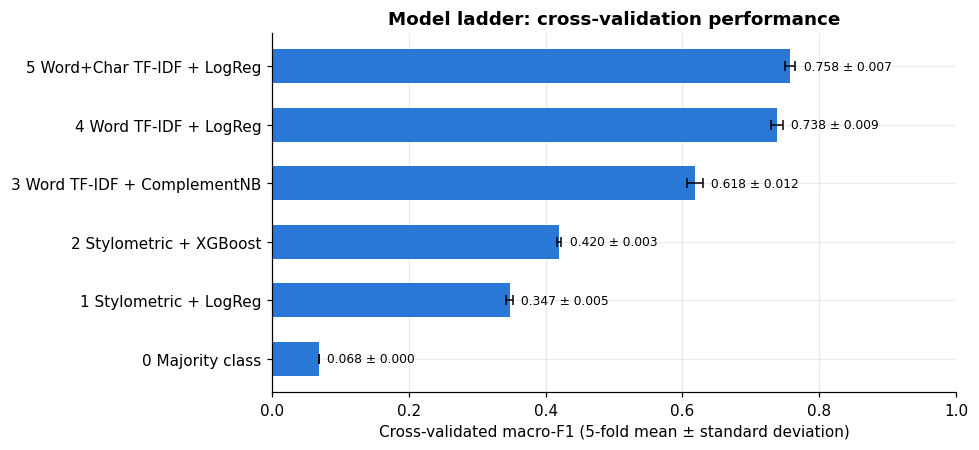

In [10]:
# 6. RQ2: MODEL LADDER — STRATIFIED CROSS-VALIDATION

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

ladder = model_ladder(RANDOM_STATE, include_xgb=True)

scoring = {
    "macro_f1": "f1_macro",
    "balanced_acc": "balanced_accuracy",
    "accuracy": "accuracy",
}

rows = []

for name, pipe in ladder.items():
    start_time = time.time()

    # Avoid parallelizing both CV folds and XGBoost simultaneously.
    cv_jobs = 1 if "XGBoost" in name else -1

    results = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=cv_jobs,
        error_score="raise",
        return_train_score=False,
    )

    macro_scores = results["test_macro_f1"]
    balanced_scores = results["test_balanced_acc"]
    accuracy_scores = results["test_accuracy"]

    rows.append({
        "model": name,
        "macro_f1": macro_scores.mean(),
        "macro_f1_sd": macro_scores.std(ddof=1),
        "balanced_acc": balanced_scores.mean(),
        "balanced_acc_sd": balanced_scores.std(ddof=1),
        "accuracy": accuracy_scores.mean(),
        "accuracy_sd": accuracy_scores.std(ddof=1),
        "fit_s_per_fold": results["fit_time"].mean(),
        "total_elapsed_s": time.time() - start_time,
    })

    print(
        f"{name:<34} "
        f"Macro-F1: {macro_scores.mean():.4f} "
        f"± {macro_scores.std(ddof=1):.4f}  "
        f"| Balanced accuracy: {balanced_scores.mean():.4f}  "
        f"| Accuracy: {accuracy_scores.mean():.4f}  "
        f"| Elapsed: {rows[-1]['total_elapsed_s']:.1f}s"
    )

# Rank models by the primary metric.
cv_table = (
    pd.DataFrame(rows)
    .set_index("model")
    .sort_values("macro_f1", ascending=False)
)

cv_table.to_csv(REPORT_DIR / "cv_model_ladder.csv")

print("\nCross-validation results, ranked by macro-F1:")
display(
    cv_table.style.format({
        "macro_f1": "{:.4f}",
        "macro_f1_sd": "{:.4f}",
        "balanced_acc": "{:.4f}",
        "balanced_acc_sd": "{:.4f}",
        "accuracy": "{:.4f}",
        "accuracy_sd": "{:.4f}",
        "fit_s_per_fold": "{:.1f}",
        "total_elapsed_s": "{:.1f}",
    })
)

# Visualize mean macro-F1 and fold-to-fold standard deviation.
plot_table = cv_table.sort_values("macro_f1", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.2))

ax.barh(
    plot_table.index,
    plot_table["macro_f1"],
    xerr=plot_table["macro_f1_sd"],
    color=PALETTE[0],
    height=0.58,
    error_kw={"elinewidth": 1, "capsize": 3},
)

for y, (_, row) in enumerate(plot_table.iterrows()):
    mean_score = row["macro_f1"]
    sd_score = row["macro_f1_sd"]

    ax.text(
        min(mean_score + sd_score + 0.012, 0.97),
        y,
        f"{mean_score:.3f} ± {sd_score:.3f}",
        va="center",
        fontsize=8,
    )

ax.set_xlim(0, 1.0)
ax.set_xlabel(
    f"Cross-validated macro-F1 "
    f"({CV_FOLDS}-fold mean ± standard deviation)"
)
ax.set_title("Model ladder: cross-validation performance")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

fig.tight_layout()
savefig("model_ladder")
plt.show()

The cross-validation results show that the TF-IDF-based text classifiers
substantially outperform the stylometric models.

The majority-class baseline achieved a macro-F1 of 0.0682. Logistic
Regression using the 12 stylometric features achieved 0.3474, while
stylometric XGBoost achieved 0.4201. These results suggest that
writing-style features contain predictive information, but do not
capture enough information to match the text-based models.

Word TF-IDF with Complement Naive Bayes achieved a macro-F1 of 0.6183.
Word TF-IDF with Logistic Regression improved this to 0.7382.

The best-performing candidate was Logistic Regression using combined
word- and character-level TF-IDF features, which achieved a mean
macro-F1 of **0.7579 ± 0.0074**, balanced accuracy of **0.7635**,
and accuracy of **0.7980**.

Compared with word-only TF-IDF, adding character features increased
macro-F1 by approximately 0.0197, or 1.97 percentage points.
However, the combined model required approximately 4.1 times the mean
training time per fold (284.7 seconds versus 69.3 seconds).

### RQ2 Conclusion

Among the six evaluated configurations, word-and-character TF-IDF
with Logistic Regression achieved the highest mean cross-validated
macro-F1. It is therefore the leading candidate for further evaluation.

The improvement over word-only TF-IDF is promising, although the
cross-validation results alone do not establish statistical significance.
Final selection should also consider per-class performance, probability
calibration, computational cost, and performance on the untouched
test set.

## 7. Hyperparameter Search

The leading candidate from the model ladder is selected for further
hyperparameter optimization. Based on the cross-validation results,
the primary candidate is **Logistic Regression with combined word-
and character-level TF-IDF features**. Word-only TF-IDF with Logistic
Regression remains a useful alternative because it is substantially
faster to train.

### Search Strategy

A randomized search explores alternative configurations of the selected
TF-IDF and Logistic Regression pipeline. The search includes:

- **Regularization strength (`C`):** Sampled from a log-uniform
  distribution to explore values across several orders of magnitude.
- **N-gram ranges:** Alternative word- and character-level n-gram
  configurations are evaluated to assess the contribution of different
  textual patterns.

The search uses a stratified subsample of the training split to reduce
computational cost while preserving class proportions as closely as
possible. The selected configuration is then refitted using the full
training split.

### Model Selection and Leakage Prevention

Hyperparameter selection uses cross-validation restricted to the training
data. Any vectorizer or other data-dependent preprocessing step must
remain inside the pipeline so it is fitted independently within each
cross-validation fold.

The calibration split is reserved for probability calibration and
conformal prediction. The test split remains untouched until the final
evaluation.

### Rationale

Logistic Regression provides a strong linear baseline for sparse
TF-IDF representations and exposes feature coefficients that can be
examined to understand model associations with particular words or
character patterns.

The combined word-and-character representation achieved the highest
mean cross-validated macro-F1 in the initial model comparison, although
its improvement over word-only TF-IDF was modest relative to its
additional computational cost.

The objective of this search is to determine whether alternative
hyperparameter configurations improve performance sufficiently to
justify the selected model's complexity and training cost.

In [11]:
# 7. HYPERPARAMETER SEARCH

# Create a stratified subsample from the training split.
if len(X_train) > TUNE_SAMPLE:
    X_tune, _, y_tune, _ = train_test_split(
        X_train,
        y_train,
        train_size=TUNE_SAMPLE,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )
else:
    X_tune, y_tune = X_train, y_train

print(f"Full training set: {len(X_train):,} posts")
print(f"Tuning subset:     {len(X_tune):,} posts")

# Select the best linear TF-IDF family from the model ladder.
linear_rungs = [
    "4 Word TF-IDF + LogReg",
    "5 Word+Char TF-IDF + LogReg",
]

FINAL_FAMILY = cv_table.loc[linear_rungs, "macro_f1"].idxmax()
USE_CHAR = FINAL_FAMILY.startswith("5")

print("Selected model family:", FINAL_FAMILY)

# Define the randomized search space.
prefix = "tfidf__word__" if USE_CHAR else "tfidf__"

param_dist = {
    "clf__C": loguniform(0.5, 30),
    f"{prefix}ngram_range": [(1, 1), (1, 2), (1, 3)],
    f"{prefix}min_df": [1, 2, 3],
}

if USE_CHAR:
    param_dist["tfidf__char__ngram_range"] = [
        (2, 4),
        (3, 5),
    ]

# Use a three-fold stratified search to limit computational cost.
search_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

search_pipeline = model_ladder(
    RANDOM_STATE,
    include_xgb=False,
)[FINAL_FAMILY]

search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=param_dist,
    n_iter=SEARCH_ITER,
    scoring="f1_macro",
    cv=search_cv,
    random_state=RANDOM_STATE,
    n_jobs=2,
    refit=False,
    error_score="raise",
)

# Tune only on the training subset.
t0 = time.time()
search.fit(X_tune, y_tune)

print(f"Search completed in {time.time() - t0:.1f} seconds")

# Inspect the leading configurations.
search_results = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_score")
    [[
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]]
)

display(search_results.head(5))

BEST_PARAMS = search.best_params_

print("Best parameters:", BEST_PARAMS)
print(f"Best tuning CV macro-F1: {search.best_score_:.4f}")

# Refit a fresh pipeline on the full training split.
final_model = model_ladder(
    RANDOM_STATE,
    include_xgb=False,
)[FINAL_FAMILY].set_params(**BEST_PARAMS)

t0 = time.time()
final_model.fit(X_train, y_train)

print(
    f"Final model refit on {len(X_train):,} training posts "
    f"in {time.time() - t0:.1f} seconds"
)

LABELS = list(final_model.classes_)

print("Model classes:", LABELS)

Full training set: 35,657 posts
Tuning subset:     20,000 posts
Selected model family: 5 Word+Char TF-IDF + LogReg
Search completed in 2075.3 seconds


,params,mean_test_score,std_test_score,rank_test_score
0,"{'clf__C': 2.3171758042400845, 'tfidf__char__n...",0.742645,0.011648,1
7,"{'clf__C': 1.6474773941090533, 'tfidf__char__n...",0.741018,0.012996,2
11,"{'clf__C': 6.015568027492313, 'tfidf__char__ng...",0.739845,0.010805,3
1,"{'clf__C': 12.172464913375098, 'tfidf__char__n...",0.738363,0.009046,4
3,"{'clf__C': 5.8592686909850995, 'tfidf__char__n...",0.736393,0.010531,5


Best parameters: {'clf__C': np.float64(2.3171758042400845), 'tfidf__char__ngram_range': (2, 4), 'tfidf__word__min_df': 3, 'tfidf__word__ngram_range': (1, 3)}
Best tuning CV macro-F1: 0.7426
Final model refit on 35,657 training posts in 216.6 seconds
Model classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


### Hyperparameter Search Results

Randomized hyperparameter search selected the Word + Char TF-IDF +
Logistic Regression model for further evaluation.

The search evaluated configurations using three-fold stratified
cross-validation on a 20,000-post subset of the training split.
The best configuration achieved a mean macro-F1 of **0.7426**
with a fold-to-fold standard deviation of **0.0116**.

The selected hyperparameters were:

| Hyperparameter | Selected value |
|---|---|
| Logistic Regression regularization strength (`C`) | 2.3172 |
| Word n-gram range | (1, 3) |
| Word minimum document frequency (`min_df`) | 3 |
| Character n-gram range | (2, 4) |

The selected configuration was subsequently refitted on the complete
training split of 35,657 posts. The refit completed in approximately
216.6 seconds.

The tuning score is a model-selection result, not the final estimate
of generalization performance. It was obtained using a different
cross-validation setup from the initial model-ladder experiment.
Consequently, the two scores should not be interpreted as a direct
before-and-after comparison.

The fitted model is now ready for the next evaluation stages, with
the calibration split reserved for probability calibration and
conformal prediction, and the test split reserved for final evaluation.

## 8. RQ3a: Probability Calibration

Classification models produce predicted probabilities, but these probabilities
are not necessarily reliable measures of confidence. For example, among
predictions assigned a probability of 0.90, approximately 90% should be
correct if the model is well calibrated.

Regularized Logistic Regression trained on high-dimensional TF-IDF features
may produce miscalibrated probabilities. Class weighting, used to address
the dataset's class imbalance, can also affect the relationship between
predicted probabilities and observed class frequencies.

### Temperature Scaling

This experiment applies **temperature scaling**, a post-hoc probability
calibration method introduced by Guo et al. (2017).

Temperature scaling divides the model's logits by a positive scalar
temperature, \(T\), before applying the softmax function:

\[
p_k(x;T) =
\frac{\exp(z_k(x)/T)}
{\sum_{j=1}^{K}\exp(z_j(x)/T)}
\]

where \(z_k(x)\) is the logit for class \(k\), and \(K\) is the number
of classes.

The temperature is fitted on **calibration half A**, which is separate
from the data used to train the classifier. The fitted temperature is
then applied to subsequent predictions without retraining the underlying
classifier.

- \(T > 1\) generally produces softer, less concentrated probabilities.
- \(0 < T < 1\) generally produces sharper, more concentrated probabilities.
- \(T = 1\) leaves the original probabilities unchanged.

Because the same positive temperature is applied to every class logit,
the ordering of the logits for an individual example remains unchanged.
Consequently, the predicted class and argmax-based classification metrics
remain unchanged, apart from potential numerical or tie-handling edge cases.

### Evaluation

Calibration performance should be assessed before and after temperature
scaling using metrics such as:

- **Negative log-likelihood (NLL):** evaluates the quality of the
  predicted probability assigned to the true class.
- **Brier score:** measures the squared error between predicted
  probabilities and one-hot encoded outcomes.
- **Expected calibration error (ECE):** summarizes differences between
  predicted confidence and observed accuracy across confidence bins.
- **Reliability diagrams:** visualize agreement between predicted
  confidence and observed accuracy.

Improvement is not assumed in advance. The results must establish whether
temperature scaling improves probability calibration on the held-out
calibration data.

The calibration split is reserved for calibration procedures, while the
test split remains untouched until the final evaluation.

**Important limitation:** Calibration indicates how well predicted
probabilities agree with observed outcomes for the evaluated data
distribution. It does not establish clinical validity, diagnostic accuracy,
or suitability for mental-health screening.

Calibration half A: 3,821 posts
Calibration half B: 3,821 posts
Fitted temperature T = 0.891 (T > 1 softens probabilities; 0 < T < 1 sharpens probabilities)


,uncalibrated,temperature-scaled
log_loss,0.5216,0.5172
brier,0.2810,0.2807
ece,0.0225,0.0168
macro_f1,0.7715,0.7715


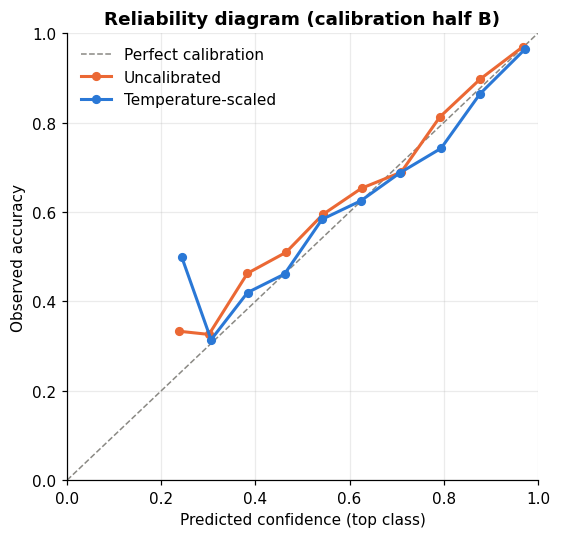

In [12]:
# 8. RQ3a: PROBABILITY CALIBRATION

# Split the calibration set into two independent subsets:
# A: fit the temperature scaler
# B: evaluate probability calibration
X_calA, X_calB, y_calA, y_calB = train_test_split(
    X_cal,
    y_cal,
    test_size=0.5,
    stratify=y_cal,
    random_state=RANDOM_STATE,
)

print(f"Calibration half A: {len(X_calA):,} posts")
print(f"Calibration half B: {len(X_calB):,} posts")

# Fit temperature scaling using calibration half A only.
logits_calA = final_model.decision_function(X_calA)

ts = TemperatureScaler(LABELS).fit(
    logits_calA,
    y_calA,
)

print(
    f"Fitted temperature T = {ts.temperature_:.3f} "
    "(T > 1 softens probabilities; 0 < T < 1 sharpens probabilities)"
)

# Evaluate on calibration half B, which was not used to fit T.
logits_calB = final_model.decision_function(X_calB)

proba_raw = final_model.predict_proba(X_calB)
proba_cal = ts.predict_proba(logits_calB)

# Calculate metrics before and after temperature scaling.
pred_raw = final_model.predict(X_calB)
pred_cal = np.array(LABELS)[proba_cal.argmax(axis=1)]

calib = pd.DataFrame({
    "uncalibrated": classification_metrics(
        y_calB, pred_raw, proba_raw, LABELS
    ),
    "temperature-scaled": classification_metrics(
        y_calB, pred_cal, proba_cal, LABELS
    ),
}).loc[["log_loss", "brier", "ece", "macro_f1"]]

display(calib.style.format("{:.4f}"))

# Reliability diagram on calibration half B.
fig, ax = plt.subplots(figsize=(5.2, 5))

ax.plot(
    [0, 1],
    [0, 1],
    ls="--",
    color="#8a8984",
    lw=1,
    label="Perfect calibration",
)

for name, probabilities, color in [
    ("Uncalibrated", proba_raw, PALETTE[1]),
    ("Temperature-scaled", proba_cal, PALETTE[0]),
]:
    reliability = reliability_table(
        y_calB,
        probabilities,
        LABELS,
        n_bins=12,
    )

    ax.plot(
        reliability["confidence"],
        reliability["accuracy"],
        marker="o",
        ms=5,
        lw=2,
        color=color,
        label=name,
    )

ax.set_xlabel("Predicted confidence (top class)")
ax.set_ylabel("Observed accuracy")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Reliability diagram (calibration half B)")
ax.legend(frameon=False)

fig.tight_layout()
savefig("reliability_diagram")
plt.show()

Temperature scaling was fitted on calibration half A, producing a
temperature of **T = 0.891**. The fitted temperature was then evaluated
on the separate calibration half B.

Compared with the uncalibrated probabilities, temperature scaling
reduced log loss from 0.5216 to 0.5172, the Brier score from 0.2810
to 0.2807, and expected calibration error (ECE) from 0.0225 to 0.0168.

The reduction in ECE was approximately 25.3%, indicating improved
agreement between predicted confidence and observed accuracy under
the selected binning procedure. The improvements in log loss and
Brier score were smaller but consistent with the ECE result.

Macro-F1 remained unchanged at 0.7715. This is expected because
temperature scaling divides every class logit by the same positive
scalar, preserving the predicted class for each observation.

The fitted temperature was below 1, which sharpened the predicted
probability distributions. This suggests that greater confidence
improved the calibration metrics on calibration half B, although the
temperature alone does not fully characterize the model's calibration.

**RQ3a conclusion:** Temperature scaling improved the measured
probability-calibration metrics on the held-out calibration subset
without changing macro-F1. The untouched test set is still required
to assess final generalization and calibration performance.

## 9. RQ2: Final Evaluation on the Held-Out Test Set

This section reports the final performance of the selected model on the
held-out test set. The test set has not been used for training,
hyperparameter selection, or probability calibration.

The selected Word + Char TF-IDF + Logistic Regression pipeline was
refitted on the complete training split after hyperparameter selection.
Temperature scaling was fitted separately using calibration half A.

### Evaluation Protocol

The final evaluation reports classification performance using:

- **Macro-F1:** The primary metric, giving equal weight to each class.
- **Balanced accuracy:** The average recall across classes.
- **Accuracy:** The proportion of correctly classified observations.
- **Per-class precision, recall, and F1:** To identify differences in
  performance across the seven categories.
- **Log loss, Brier score, and expected calibration error (ECE):**
  To assess the quality of predicted probabilities.

The fitted temperature is applied to the test predictions without
further adjustment. Both uncalibrated and temperature-scaled
probabilities are evaluated.

### Bootstrap Confidence Interval

A 95% percentile bootstrap confidence interval is calculated for
test-set macro-F1 by repeatedly resampling test observations with
replacement and recalculating macro-F1 for each resample.

The interval estimates uncertainty associated with the finite test
sample. It does not capture variability arising from retraining the
model, choosing different training samples, or repeating the
hyperparameter-selection procedure.

**Test-set integrity:** The test set is used only for this final
evaluation. Its results must not be used to adjust hyperparameters,
select calibration methods, or make further model-development decisions.

In [13]:
# Generate predictions on the held-out test set.
# The model and temperature scaler have already been fitted without test data.
logits_test = final_model.decision_function(X_test)
proba_test_raw = final_model.predict_proba(X_test)
proba_test_cal = ts.predict_proba(logits_test)

y_pred_test = np.asarray(LABELS)[proba_test_cal.argmax(axis=1)]

FINAL_NAME = f"★ Final: tuned {FINAL_FAMILY[2:]} (calibrated)"

# Refit the two reference models on the full training split for comparison.
ref_models = {
    k: ladder[k]
    for k in ["0 Majority class", "2 Stylometric + XGBoost"]
}

test_rows = {}

for name, model in ref_models.items():
    model.fit(X_train, y_train)

    y_ref_pred = model.predict(X_test)
    proba_ref = model.predict_proba(X_test)

    test_rows[name] = classification_metrics(
        y_test, y_ref_pred, proba_ref, LABELS
    )

# Evaluate the final model using temperature-scaled test probabilities.
test_rows[FINAL_NAME] = classification_metrics(
    y_test, y_pred_test, proba_test_cal, LABELS
)

test_table = pd.DataFrame(test_rows).T
display(test_table.style.format("{:.4f}", na_rep="–"))

# Bootstrap confidence interval for test-set macro-F1.
point, lo, hi = bootstrap_ci(
    y_test,
    y_pred_test,
    n_boot=N_BOOT,
    random_state=RANDOM_STATE
)

print(
    f"Final model macro-F1 = {point:.4f} "
    f"(95% bootstrap CI {lo:.4f}–{hi:.4f}, "
    f"n_test = {len(y_test):,})"
)

# Per-class precision, recall, and F1 for the final model.
report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_test,
        labels=LABELS,
        output_dict=True,
        zero_division=0
    )
).T

display(
    report.style.format(
        {
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1-score": "{:.3f}",
            "support": "{:,.0f}",
        }
    )
)

,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss,ece,brier
0 Majority class,0.3136,0.1429,0.0682,0.1497,24.7414,0.6864,1.3729
2 Stylometric + XGBoost,0.5573,0.4530,0.4075,0.5678,1.0899,0.0357,0.5385
★ Final: tuned Word+Char TF-IDF + LogReg (calibrated),0.8009,0.7722,0.7574,0.8012,0.5169,0.0130,0.2792


Final model macro-F1 = 0.7574 (95% bootstrap CI 0.7428–0.7716, n_test = 7,641)


,precision,recall,f1-score,support
Anxiety,0.820,0.848,0.834,541
Bipolar,0.812,0.816,0.814,375
Depression,0.792,0.705,0.746,"2,259"
Normal,0.924,0.936,0.930,"2,396"
Personality disorder,0.596,0.627,0.611,134
Stress,0.580,0.729,0.646,343
Suicidal,0.700,0.745,0.721,"1,593"
accuracy,0.801,0.801,0.801,1
macro avg,0.746,0.772,0.757,"7,641"
weighted avg,0.804,0.801,0.801,"7,641"


## Final Evaluation on the Held-Out Test Set

The selected Word + Character TF-IDF + Logistic Regression model
was evaluated on the held-out test set after hyperparameter selection
and probability calibration were completed using separate data splits.

### Overall Performance

The final model achieved:

- **Accuracy:** 0.8009
- **Balanced accuracy:** 0.7722
- **Macro-F1:** 0.7574
- **Weighted-F1:** 0.8012
- **Log loss:** 0.5169
- **Expected calibration error (ECE):** 0.0130
- **Brier score:** 0.2792

The 95% percentile-bootstrap confidence interval for macro-F1 was
**0.7428–0.7716**, based on 7,641 test observations.

Macro-F1 is the primary evaluation metric because it gives equal
weight to all seven classes despite their unequal representation.
The difference between macro-F1 and weighted-F1 highlights the
importance of examining performance across individual categories
rather than relying on overall accuracy alone.

### Comparison with Reference Models

The final model achieved a macro-F1 of 0.7574, compared with 0.4075
for the stylometric XGBoost reference model and 0.0682 for the
majority-class baseline.

These results support the use of lexical and character-level
TF-IDF representations for this dataset and classification task.
However, the comparison does not isolate the contribution of
individual features or establish performance on external datasets.

### Per-Class Performance

Performance varied across the seven categories. The Normal category
achieved the highest F1-score (0.930), followed by Anxiety (0.834)
and Bipolar (0.814).

Depression had a recall of 0.705, while Stress had a precision of
0.580. Personality disorder had the lowest F1-score (0.611), based
on 134 test observations. These results indicate that overall
performance conceals meaningful differences between categories.

### Interpretation and Limitations

The results demonstrate promising performance on a held-out sample
from the dataset. They do not establish clinical validity, diagnostic
accuracy, or generalization to other populations and sources of text.

The category labels are dataset annotations, not verified clinical
diagnoses. This model is an exploratory text-classification system
and must not be used independently for mental-health diagnosis,
suicide-risk assessment, or treatment decisions.

The bootstrap confidence interval reflects uncertainty from
resampling the observed test set. It does not capture variation
from retraining, data selection, or hyperparameter optimization.

**Test-set integrity:** The held-out test set was reserved for final
evaluation. Its results should not be used for further model tuning.

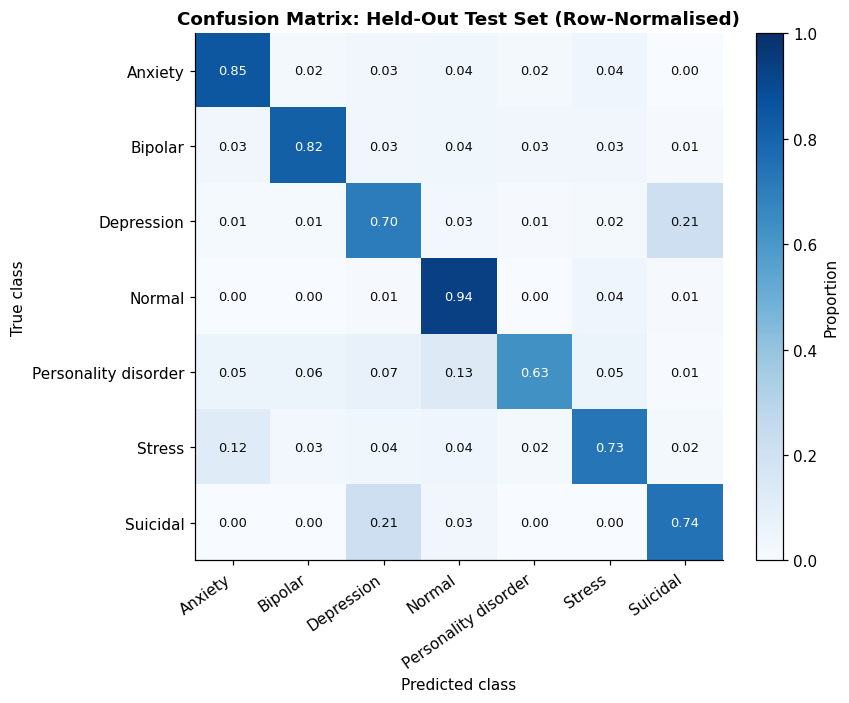

In [14]:
# Row-normalised confusion matrix for the held-out test set.
cm = confusion_matrix(
    y_test,
    y_pred_test,
    labels=LABELS,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 6.5))

im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=35, ha="right")
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)

# Annotate each cell with its row-normalised proportion.
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(
            j, i, f"{cm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8.5,
            color="white" if cm[i, j] > 0.55 else "#0b0b0b"
        )

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Confusion Matrix: Held-Out Test Set (Row-Normalised)")
ax.grid(False)

fig.colorbar(im, ax=ax, fraction=0.046, label="Proportion")
fig.tight_layout()

savefig("confusion_matrix")
plt.show()

**What to look for**

The off-diagonal cells reveal which categories the model tends to confuse.

- **Depression ↔ Suicidal:** Examine whether the model confuses these categories. Their language may overlap, but the confusion matrix alone cannot establish whether errors arise from ambiguous labels, shared linguistic patterns, or limitations in the model.
- **Stress ↔ Anxiety:** Investigate whether posts assigned to these categories are frequently confused, potentially reflecting similar expressions of distress.

These patterns may reflect both classification errors and ambiguity in the dataset's category boundaries. The confusion matrix identifies where errors occur, but additional qualitative analysis would be needed to understand why.

This motivates the prediction sets introduced in the next section. Instead of always returning a single category, a set-valued predictor can return multiple plausible labels, such as *Depression or Suicidal*, when the method's criteria support including both. This represents predictive uncertainty; it does not establish that either label is clinically correct.

## 10. RQ3b: Conformal Prediction Sets (Distribution-Free Uncertainty)

A conventional classifier returns one predicted label, even when
several classes have similar predicted probabilities. **Split-conformal
prediction** extends the classifier to produce a *prediction set*
containing one or more candidate labels.

For a target miscoverage rate of $\alpha = 0.10$, the objective is
90% coverage: the prediction set should contain the true label for
approximately 90% of future observations under the conformal
method's exchangeability assumption.

### Nonconformity Score

This experiment uses **Least Ambiguous Class (LAC)** nonconformity
scores:

$$
s(x,y) = 1 - \hat{p}_y(x)
$$

Here, $\hat{p}_y(x)$ is the model's predicted probability for the
true class $y$. A larger score indicates that the model assigned
a lower probability to the observed class.

The calibration scores are computed on **calibration half B**,
which was not used to fit the temperature scaler. The resulting
conformal threshold is then applied to predictions for new observations.

### Two Coverage Strategies

- **Marginal split conformal:** Uses a single calibration threshold
  across all classes. Under exchangeability, it provides a finite-sample
  marginal coverage guarantee of at least $1-\alpha$, subject to the
  standard split-conformal quantile construction.

- **Class-conditional (Mondrian) conformal:** Computes separate
  calibration thresholds for each true class. Under exchangeability
  within each class and a valid class-specific quantile construction,
  this targets coverage of at least $1-\alpha$ within each class.
  Rare classes have fewer calibration examples, so their thresholds
  and prediction sets may be less stable or larger.

### Interpretation and Limitations

Coverage measures how often the prediction set contains the true
dataset label. It does not guarantee that every included label is
correct, that the set is clinically meaningful, or that the model
generalizes to different populations or data sources.

Class-conditional coverage is especially relevant when evaluating
minority categories, including *Suicidal*. However, conformal prediction
is an uncertainty-quantification method, not a clinical safety
mechanism or suicide-risk assessment system.

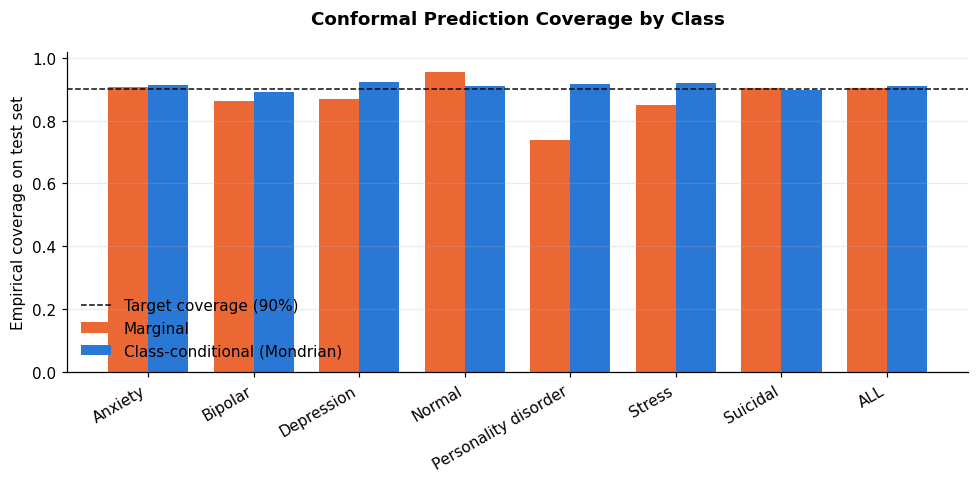

In [15]:
# Calibrated probabilities for conformal calibration.
# Calibration half B was not used to fit the temperature scaler.
proba_calB = ts.predict_proba(
    final_model.decision_function(X_calB)
)

# Fit marginal and class-conditional (Mondrian) conformal predictors.
cp_marg = SplitConformalClassifier(
    LABELS,
    alpha=ALPHA,
    class_conditional=False
).fit(proba_calB, y_calB)

cp_mond = SplitConformalClassifier(
    LABELS,
    alpha=ALPHA,
    class_conditional=True
).fit(proba_calB, y_calB)

# IMPORTANT: evaluate prediction sets on the held-out TEST probabilities.
# proba_test_cal must be generated from X_test using the fitted temperature scaler.
sets_marg_test = cp_marg.predict_sets(proba_test_cal)
sets_mond_test = cp_mond.predict_sets(proba_test_cal)

cov_marg = coverage_report(
    sets_marg_test, y_test, LABELS
).set_index("class")

cov_mond = coverage_report(
    sets_mond_test, y_test, LABELS
).set_index("class")

coverage = pd.concat(
    {
        "marginal": cov_marg,
        "class-conditional": cov_mond
    },
    axis=1
)

coverage.to_csv(REPORT_DIR / "conformal_coverage.csv")

display(
    coverage.style
    .format("{:.3f}", na_rep="–")
    .format(
        "{:,.0f}",
        subset=[
            ("marginal", "n"),
            ("class-conditional", "n")
        ]
    )
)

# Plot empirical test coverage by class.
order = [c for c in LABELS if c in cov_marg.index]
if "ALL" in cov_marg.index:
    order.append("ALL")

x = np.arange(len(order))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(
    x - w / 2,
    cov_marg.loc[order, "coverage"],
    w,
    color=PALETTE[1],
    label="Marginal"
)

ax.bar(
    x + w / 2,
    cov_mond.loc[order, "coverage"],
    w,
    color=PALETTE[0],
    label="Class-conditional (Mondrian)"
)

ax.axhline(
    1 - ALPHA,
    linestyle="--",
    linewidth=1,
    color="#0b0b0b",
    label=f"Target coverage ({1 - ALPHA:.0%})"
)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylim(0, 1.02)
ax.set_ylabel("Empirical coverage on test set")
ax.set_title("Conformal Prediction Coverage by Class", pad=18)
ax.legend(frameon=False, loc="best")
ax.grid(axis="x", visible=False)

fig.tight_layout()
savefig("conformal_coverage")
plt.show()

## Conformal Prediction Coverage

Both split-conformal methods achieved overall test coverage near or
above the 90% target. Marginal conformal achieved 90.3% coverage,
with a mean prediction-set size of 1.299 labels. Class-conditional
(Mondrian) conformal achieved 91.1% coverage, with a mean set size
of 1.422 labels.

### Class-Level Coverage

Marginal conformal showed substantial variation in coverage across
classes. Personality disorder coverage was 73.9%, Stress coverage
was 84.8%, and Depression coverage was 86.9%. Although overall
coverage met the target, these results show that marginal coverage
does not guarantee similar coverage for every category.

Mondrian conformal improved coverage for several of these classes:
Personality disorder increased to 91.8%, Stress to 92.1%, and
Depression to 92.2%. Bipolar coverage increased from 86.1% to 89.1%.
Suicidal coverage was 89.9%, while Normal coverage was 91.1%.

### Coverage–Set Size Trade-Off

The improved class-level coverage came with larger prediction sets.
Mean set size increased from 1.299 labels under marginal conformal
to 1.422 under Mondrian conformal.

This trade-off illustrates how class-conditional conformal prediction
can represent uncertainty more consistently across categories.
A prediction set may contain multiple plausible dataset labels
rather than forcing the classifier to return only one.

### Limitations

These results describe empirical coverage on the held-out test set.
The formal split-conformal guarantee depends on exchangeability
between calibration and future observations and on the correct
implementation of the conformal quantile.

Class-conditional coverage estimates for rare categories are based
on fewer test observations and are therefore less precise.
Prediction sets represent uncertainty about dataset labels; they
do not establish clinical validity or provide a mental-health
diagnosis or suicide-risk assessment.

In [16]:
# Generate Mondrian prediction sets for the held-out test set.
sets_test = cp_mond.predict_sets(proba_test_cal)
set_size = sets_test.sum(axis=1)

print(
    f"Mondrian conformal sets (test, target {1 - ALPHA:.0%} coverage) — "
    f"singletons: {(set_size == 1).mean():.1%} | "
    f"mean size: {set_size.mean():.2f} | "
    f"empty: {(set_size == 0).mean():.1%}"
)

# Inspect the most frequent two-label prediction sets.
two_label_sets = sets_test[set_size == 2]

combos = pd.Series(
    [
        " + ".join(np.asarray(LABELS)[row])
        for row in two_label_sets
    ],
    dtype="string"
).value_counts().head(8)

display(
    combos.rename("posts with a 2-label set").to_frame()
)

Mondrian conformal sets (test, target 90% coverage) — singletons: 64.0% | mean size: 1.42 | empty: 0.0%


,posts with a 2-label set
Depression + Suicidal,1591
Anxiety + Stress,100
Depression + Stress,94
Depression + Personality disorder,82
Personality disorder + Stress,74
Depression + Normal,66
Anxiety + Depression,49
Bipolar + Stress,44


### Prediction-Set Size and Label Combinations

Mondrian conformal prediction returned singleton sets for 64.0% of
held-out test posts. The mean prediction-set size was 1.42 labels,
and no empty sets were observed.

The most frequent two-label combination was **Depression + Suicidal**,
which appeared 1,591 times. The next most frequent combination was
**Anxiety + Stress**, with 100 occurrences. Other recurring combinations
included Depression + Stress (94), Depression + Personality disorder
(82), and Personality disorder + Stress (74).

The prominence of Depression + Suicidal indicates that the model
frequently retains both labels as candidates rather than selecting
one exclusively. Other combinations suggest that predictive uncertainty
also occurs across several additional categories.

These findings characterize the model's uncertainty on this dataset.
They do not establish that the labels are clinically interchangeable
or that the model can assess mental-health conditions reliably.
Qualitative inspection of representative examples would be needed
to investigate the sources of these prediction patterns.

### 10.1 LAC vs. Adaptive Prediction Sets (APS)

Least Ambiguous Class (LAC) uses the nonconformity score
$s(x,y)=1-\hat p_y(x)$ to construct prediction sets. It is simple
and often produces relatively compact sets, but its set sizes may
not fully reflect the distribution of probability mass across
competing classes.

**Adaptive Prediction Sets (APS)** use a cumulative-probability score.
For each candidate label, the score accumulates the predicted
probabilities of labels ranked at least as highly, including a
randomized fraction of the candidate label's own probability mass.
This allows the prediction set to account for the ranking and
distribution of predicted probabilities.

Randomization is part of the APS construction and can be important
for its finite-sample coverage properties. A fixed random seed makes
the experiment reproducible. The implementation should be checked
to ensure that randomization is applied consistently during
calibration and prediction.

### Evaluating Uncertainty Informativeness

A useful uncertainty signal should, ideally, distinguish correct
from incorrect top-1 predictions. This experiment compares prediction
set sizes for these two groups.

If incorrect top-1 predictions tend to have larger sets, that is
evidence that set size captures some information about predictive
difficulty. If set sizes are similar, the method may be less useful
for distinguishing correct from incorrect predictions on this dataset.

This comparison is a diagnostic, not a guarantee. Set size alone
does not establish predictive correctness, clinical validity, or
reliable uncertainty estimates for every class.

In [17]:
# Fit randomized, class-conditional APS using calibration half B.
cp_aps = SplitConformalClassifier(
    LABELS,
    alpha=ALPHA,
    class_conditional=True,
    score="aps",
    randomized=True,
    random_state=RANDOM_STATE
).fit(proba_calB, y_calB)

# Identify top-1 errors on the held-out test set.
y_pred_test = np.asarray(LABELS)[proba_test_cal.argmax(axis=1)]
top1_wrong = y_pred_test != y_test.to_numpy()


def set_summary(name, prediction_sets):
    """Summarize coverage, set size, and uncertainty informativeness."""
    cov = coverage_report(
        prediction_sets, y_test, LABELS
    ).set_index("class")

    sizes = prediction_sets.sum(axis=1)

    return {
        "method": name,
        "coverage": cov.loc["ALL", "coverage"],
        "worst-class coverage": cov.drop(index="ALL")["coverage"].min(),
        "mean set size": sizes.mean(),
        "singletons": (sizes == 1).mean(),
        "size | top-1 correct": (
            sizes[~top1_wrong].mean() if (~top1_wrong).any() else np.nan
        ),
        "size | top-1 wrong": (
            sizes[top1_wrong].mean() if top1_wrong.any() else np.nan
        ),
    }


# Generate all prediction sets for the held-out test probabilities.
sets_lac_marginal = cp_marg.predict_sets(proba_test_cal)
sets_lac_mondrian = cp_mond.predict_sets(proba_test_cal)
sets_aps_mondrian = cp_aps.predict_sets(proba_test_cal)

set_methods = pd.DataFrame([
    set_summary("LAC, marginal", sets_lac_marginal),
    set_summary("LAC, class-conditional", sets_lac_mondrian),
    set_summary("APS, class-conditional", sets_aps_mondrian),
]).set_index("method")

set_methods.to_csv(REPORT_DIR / "conformal_methods.csv")

display(
    set_methods.style
    .format("{:.3f}", na_rep="–")
    .format("{:.1%}", subset=["singletons"])
)

,coverage,worst-class coverage,mean set size,singletons,size | top-1 correct,size | top-1 wrong
method,,,,,,
"LAC, marginal",0.903,0.739,1.299,71.2%,1.211,1.655
"LAC, class-conditional",0.911,0.891,1.422,64.0%,1.313,1.859
"APS, class-conditional",0.902,0.888,1.640,51.8%,1.464,2.345


### LAC vs. APS: Results and Interpretation

All three conformal configurations achieved overall test coverage
close to the 90% target. Their trade-offs differed in prediction-set
size, class-level coverage, and the relationship between set size
and top-1 classification errors.

Marginal LAC produced the smallest sets, with a mean size of 1.299
and a singleton rate of 71.2%. However, its worst-class coverage
was only 73.9%, showing that strong marginal coverage can coexist
with substantially lower coverage for individual categories.

Mondrian LAC achieved 91.1% overall coverage and 89.1% worst-class
coverage, with a mean set size of 1.422. It therefore offered a
useful balance between prediction-set compactness and class-level
coverage in this experiment.

APS achieved 90.2% overall coverage and 88.8% worst-class coverage.
Its mean set size was larger, at 1.640, and its singleton rate was
lower, at 51.8%. However, its mean set size increased from 1.464
for correct top-1 predictions to 2.345 for incorrect predictions.
This difference suggests that APS set size captured more information
about top-1 errors in this test sample than either LAC configuration.

Overall, Mondrian LAC provided the strongest balance between
compact prediction sets and consistent empirical class coverage.
APS provided a more pronounced distinction between correct and
incorrect top-1 predictions, at the cost of larger sets.

These conclusions are specific to this dataset, model, and
evaluation setup. Empirical test results do not replace the
theoretical coverage assumptions of split-conformal prediction.

### 10.2 Optional: Fine-Tuned Transformer Baseline

Does the transparent linear model leave predictive performance on
the table? This experiment fine-tunes **DistilRoBERTa** for two
epochs and compares it with the tuned TF-IDF + Logistic Regression
model on the same held-out test posts.

The transformer uses class-weighted cross-entropy, the AdamW
optimizer, a linear learning-rate schedule with warm-up, and
mixed-precision training when supported by the hardware.

### Evaluation Protocol

To keep the comparison consistent, the transformer uses the same
training, calibration, and test partitions as the linear model.
Its probabilities are calibrated using temperature scaling, followed
by class-conditional (Mondrian) conformal prediction.

The primary comparison is the difference in test-set macro-F1.
A **paired bootstrap** resamples the same test observations for both
models and calculates the macro-F1 difference for each resample.
This estimates uncertainty in the performance difference while
accounting for the fact that both models are evaluated on the same
posts.

The experiment also compares calibration metrics and conformal
prediction-set behavior where applicable.

### Execution

This experiment is optional because transformer fine-tuning requires
additional compute and dependencies. It runs automatically when a
supported GPU is available and can be controlled with the
`SMM_TRANSFORMER` environment variable:

- `SMM_TRANSFORMER=1`: attempt to run the experiment.
- `SMM_TRANSFORMER=0`: skip the experiment.

Execution time depends on the GPU, sequence length, batch size,
and software environment.

### Interpretation

The transformer is evaluated as a competing model, not assumed to
be superior. Any improvement in macro-F1 should be weighed against
computational cost, calibration quality, prediction-set size, and
reproducibility.

In [18]:
try:
    import torch
    HAS_GPU = torch.cuda.is_available()
except ImportError:
    HAS_GPU = False

RUN_TRANSFORMER = (
    HAS_GPU if SMM_TRANSFORMER == "auto"
    else SMM_TRANSFORMER == "1"
)

transformer_summary = None

if RUN_TRANSFORMER:
    from socialmediamind.transformer import finetune

    # 1. Fine-tune the transformer using training data only.
    t0 = time.time()

    tf_model = finetune(
        X_train,
        y_train,
        LABELS,
        model_name=TRANSFORMER_NAME,
        epochs=1 if FAST_MODE else 2,
        batch_size=32,
        max_length=256,
        seed=RANDOM_STATE,
        log_every=200,
    )

    tf_minutes = (time.time() - t0) / 60

    # 2. Fit temperature scaling on calibration half A.
    tf_logits_calA = tf_model.decision_function(X_calA)

    tf_ts = TemperatureScaler(LABELS).fit(
        tf_logits_calA,
        y_calA,
    )

    # 3. Generate calibrated probabilities on the held-out test set.
    tf_logits_test = tf_model.decision_function(X_test)
    tf_proba = tf_ts.predict_proba(tf_logits_test)
    tf_pred = np.asarray(LABELS)[tf_proba.argmax(axis=1)]

    # 4. Fit Mondrian conformal using calibration half B.
    tf_proba_calB = tf_ts.predict_proba(
        tf_model.decision_function(X_calB)
    )

    tf_cp = SplitConformalClassifier(
        LABELS,
        alpha=ALPHA,
        class_conditional=True,
    ).fit(
        tf_proba_calB,
        y_calB,
    )

    # Evaluate conformal sets on the held-out test set.
    tf_sets_test = tf_cp.predict_sets(tf_proba)

    tf_cov = coverage_report(
        tf_sets_test,
        y_test,
        LABELS,
    ).set_index("class")

    # 5. Establish the linear reference using TEST predictions.
    # These must come from the final tuned linear model.
    lin_pred_test = np.asarray(y_pred_test)
    lin_proba_test = proba_test_cal

    # Ensure both models use the same test observations.
    yt = np.asarray(y_test)

    assert len(yt) == len(tf_pred) == len(lin_pred_test)
    assert len(yt) == len(tf_proba) == len(lin_proba_test)

    # 6. Paired bootstrap for the difference in macro-F1.
    # Both models are evaluated on the same resampled test indices.
    rng_b = np.random.default_rng(RANDOM_STATE)
    diffs = np.empty(N_BOOT)

    for b in range(N_BOOT):
        idx = rng_b.integers(0, len(yt), size=len(yt))

        f1_tf = f1_score(
            yt[idx],
            tf_pred[idx],
            labels=LABELS,
            average="macro",
            zero_division=0,
        )

        f1_linear = f1_score(
            yt[idx],
            lin_pred_test[idx],
            labels=LABELS,
            average="macro",
            zero_division=0,
        )

        diffs[b] = f1_tf - f1_linear

    d_lo, d_hi = np.quantile(diffs, [0.025, 0.975])

    # Point estimates for both models on the SAME test set.
    lin_m = classification_metrics(
        y_test,
        lin_pred_test,
        lin_proba_test,
        LABELS,
    )

    tf_m = classification_metrics(
        y_test,
        tf_pred,
        tf_proba,
        LABELS,
    )

    # 7. Compare predictive performance and uncertainty behavior.
    comparison = pd.DataFrame({
        "linear (final)": {
            **lin_m,
            "conformal mean set size":
                cov_mond.loc["ALL", "mean_set_size"],
            "worst-class coverage":
                cov_mond.drop(index="ALL")["coverage"].min(),
        },
        TRANSFORMER_NAME: {
            **tf_m,
            "conformal mean set size":
                tf_cov.loc["ALL", "mean_set_size"],
            "worst-class coverage":
                tf_cov.drop(index="ALL")["coverage"].min(),
        },
    })

    display(comparison.style.format("{:.4f}", na_rep="–"))

    delta_f1 = tf_m["macro_f1"] - lin_m["macro_f1"]

    print(
        f"Δ macro-F1 (transformer − linear) = {delta_f1:+.4f} "
        f"[95% paired-bootstrap CI {d_lo:+.4f}, {d_hi:+.4f}] "
        f"| fine-tuning took {tf_minutes:.1f} min"
    )

    # Save a compact summary for subsequent reporting.
    transformer_summary = {
        "model": TRANSFORMER_NAME,
        "minutes": tf_minutes,
        "temperature": tf_ts.temperature_,
        **{f"test_{k}": v for k, v in tf_m.items()},
        "delta_macro_f1": delta_f1,
        "delta_ci95": [d_lo, d_hi],
        "conformal_mean_set_size":
            float(tf_cov.loc["ALL", "mean_set_size"]),
        "conformal_worst_class_coverage":
            float(tf_cov.drop(index="ALL")["coverage"].min()),
    }

else:
    if SMM_TRANSFORMER == "0":
        print("Transformer baseline explicitly disabled by SMM_TRANSFORMER=0.")
    elif not HAS_GPU:
        print(
            "Transformer baseline skipped because no CUDA GPU was detected. "
            "Use a GPU runtime or set SMM_TRANSFORMER=1 to attempt execution."
        )

Transformer baseline skipped because no CUDA GPU was detected. Use a GPU runtime or set SMM_TRANSFORMER=1 to attempt execution.


### How to Judge the Trade-Off

The primary comparison is the paired-bootstrap confidence interval
for the difference in test macro-F1:

$$
\Delta F_1 =
F_{1,\text{transformer}} - F_{1,\text{linear}}
$$

- **Confidence interval entirely above zero:** Evidence that the
  transformer achieves higher macro-F1 on this test distribution.
  Assess whether the improvement is practically meaningful relative
  to its computational cost and operational complexity.

- **Confidence interval includes zero:** The observed difference is
  inconclusive under this bootstrap analysis. The linear model remains
  a defensible choice, particularly if its interpretability, speed,
  and simpler deployment are priorities.

- **Confidence interval entirely below zero:** Evidence that the
  linear model achieves higher macro-F1 on this test distribution.

The transformer may offer improved predictive performance, but this
must be weighed against training time, inference latency, resource
requirements, and reduced interpretability. Logistic Regression
provides direct access to feature coefficients, although these are
associations with model predictions rather than causal explanations.

### Conformal Prediction Comparison

Split-conformal prediction can be applied to either model. Each model
must use its own calibration scores and conformal thresholds, fitted
without using test labels.

Under the relevant exchangeability assumptions and a correct
implementation, the methods provide their corresponding coverage
guarantees. However, empirical coverage and prediction-set sizes can
differ between models.

A stronger classifier may produce smaller prediction sets at a
similar coverage level, but this is an empirical possibility rather
than a guarantee. Compare coverage, mean set size, singleton rate,
and class-specific coverage together.

The final model choice should balance predictive performance,
uncertainty quality, interpretability, computational cost, and
deployment requirements.

## 11. RQ4: Explainability

This section examines model behavior at three complementary levels.

1. **Global text-model interpretation:** Identify the highest-weighted
   word and character n-grams associated with each class in the
   tuned Logistic Regression model.

2. **Local text-model interpretation:** Decompose an individual
   prediction into additive feature contributions. For the linear
   classifier, each feature's contribution is calculated from its
   learned coefficient multiplied by its TF-IDF value. This provides
   an exact decomposition of the model's decision score relative to
   a zero-feature baseline.

3. **SHAP for stylometric XGBoost:** Use SHAP values to examine how
   the 12 interpretable stylometric features contribute to predictions
   from the non-linear XGBoost model.

These methods provide complementary views of the fitted models:
global feature associations, individual prediction contributions,
and non-linear feature effects.

**Interpretation boundary:** These explanations describe model
behavior, not the psychological states, intentions, or clinical
conditions of the people who wrote the posts. Learned weights and
feature attributions are not evidence of causation or clinical validity.

In [19]:
# Extract the highest-weighted features for each class.
top_terms = top_terms_per_class(final_model, n=12)

# Keep a consistent class order across the notebook.
top_terms = top_terms[
    [label for label in LABELS if label in top_terms.columns]
]

# Save the results for reporting and reproducibility.
top_terms.to_csv(
    REPORT_DIR / "top_terms_per_class.csv",
    index=False
)

display(top_terms)

,Anxiety,Bipolar,Depression,Normal,Personality disorder,Stress,Suicidal
0,restless,bipolar,depression,her,avpd,stress,do not
1,worry,manic,do not,wa,do you,stressed,i am
2,worried,meds,i am,url,avoidant,https,die
3,anxiety,mania,i do not,he,social,he,i do not
4,nervous,lithium,wa,t,this disorder,and,am
5,anxious,my meds,cannot,or not,them,com,kill
6,cancer,bp,i do,she,shame,i,i do
7,health anxiety,on,not,yes,with avpd,dr,cannot
8,heart,episode,am,quot,lol,ptsd,to die
9,hopeful,latuda,it is,met,it's,tl dr,do it


### Global Interpretation: Highest-Weighted Features

The highest-weighted features reveal several patterns in the fitted
multiclass Logistic Regression model.

Some features are semantically relevant to their associated dataset
categories. Examples include *restless* and *worry* for Anxiety,
*mania* and *lithium* for Bipolar, and *suicide* and *to die* for
Suicidal.

Other high-weighted features are generic expressions, including
*do not*, *i am*, and personal pronouns. Their prominence suggests
that the model may rely partly on linguistic style and recurring
phrases, rather than exclusively on category-specific terminology.

Potential formatting artifacts, including *url*, *https*, and *tl dr*,
also warrant investigation. Their presence does not establish data
leakage, but they may indicate source-specific patterns that affect
generalization.

These coefficients describe associations learned by the classifier.
They do not establish causal relationships, clinical validity, or
the psychological state of the authors. Further analysis would be
needed to distinguish useful linguistic signals from dataset artifacts.

In [20]:
rng = np.random.default_rng(RANDOM_STATE)

y_test_array = np.asarray(y_test)
correct_idx = np.flatnonzero(y_pred_test == y_test_array)
wrong_idx = np.flatnonzero(y_pred_test != y_test_array)

for kind, pool in [("correct", correct_idx), ("misclassified", wrong_idx)]:
    if len(pool) == 0:
        print(f"No {kind} examples available.")
        continue

    i = int(rng.choice(pool))
    text = X_test.iloc[i]
    prediction_set = np.asarray(LABELS)[sets_mond_test[i]]

    print(
        f"\n--- {kind}: true = {y_test_array[i]} | "
        f"predicted = {y_pred_test[i]} | "
        f"90% set = {prediction_set.tolist()} | "
        f"words = {len(text.split())}"
    )

    if SHOW_TEXT_EXAMPLES:
        print(text[:300] + ("…" if len(text) > 300 else ""))

    display(
        explain_text(final_model, text, n=10)
        .style.format({"contribution": "{:+.3f}"})
    )


--- correct: true = Suicidal | predicted = Suicidal | 90% set = ['Suicidal'] | words = 97


,predicted_class,feature,contribution
0,Suicidal,word__die,+0.289
1,Suicidal,word__do not,+0.266
2,Suicidal,word__to die,+0.226
3,Suicidal,char__ die,+0.148
4,Suicidal,char__cid,+0.129
5,Suicidal,char__die,+0.128
6,Suicidal,word__not,+0.111
7,Suicidal,char__not,+0.108
8,Suicidal,word__suicide,+0.105
9,Suicidal,char__not,+0.097



--- misclassified: true = Depression | predicted = Stress | 90% set = ['Stress'] | words = 544


,predicted_class,feature,contribution
0,Stress,char__.,+0.116
1,Stress,char__'t,+0.099
2,Stress,char__n't,+0.098
3,Stress,char__n',+0.096
4,Stress,char__'t,+0.095
5,Stress,char__n't,+0.095
6,Stress,word__and,+0.080
7,Stress,char__i',+0.067
8,Stress,word__i,+0.066
9,Stress,"char__,",+0.063


## Error Analysis: Where and How Does the Model Fail?

This section investigates the final model's errors on the held-out test set.

The analysis examines:
1. **Confusion patterns:** Which pairs of classes are most frequently confused?
2. **Prediction confidence:** Does the model make high-confidence mistakes?
3. **Conformal uncertainty:** Do prediction sets contain the true label when the top-1 prediction is wrong?
4. **Representative errors:** What patterns appear in selected misclassified examples?
5. **Explanation quality:** Do local explanations highlight meaningful features or reveal implementation artifacts?

We report both the frequency of each error type and its rate within the corresponding true class. This distinction matters because a common error may reflect a large class, while a high class-specific error rate may expose a weakness affecting a smaller group.

This is an exploratory analysis of dataset labels and model behavior, not an evaluation of clinical diagnosis. The labels are not independently verified clinical assessments.

**Evaluation discipline:** The test set is used for analysis, not repeated model selection. Findings may motivate future experiments, but any revised model should be selected using training and validation data and evaluated on an appropriately untouched test set.

In [21]:
# Validate that all final test outputs refer to the same observations.
y_true = np.asarray(y_test)
y_pred = np.asarray(y_pred_test)
proba = np.asarray(proba_test_cal)
prediction_sets = np.asarray(sets_mond_test, dtype=bool)

assert len(y_true) == len(y_pred) == len(proba) == len(prediction_sets)
assert proba.shape == (len(y_true), len(LABELS))
assert prediction_sets.shape == (len(y_true), len(LABELS))
assert list(final_model.classes_) == list(LABELS)

# Count correct and incorrect predictions for every class pair.
cm = confusion_matrix(y_true, y_pred, labels=LABELS)

# Normalize each row by its true-class count.
# Each row shows how observations from that true class were classified.
row_totals = cm.sum(axis=1, keepdims=True)
cm_normalized = np.divide(
    cm,
    row_totals,
    out=np.zeros_like(cm, dtype=float),
    where=row_totals != 0,
)

print(f"Test observations: {len(y_true):,}")
print(f"Correct predictions: {(y_true == y_pred).sum():,}")
print(f"Misclassifications: {(y_true != y_pred).sum():,}")
print(f"Overall error rate: {(y_true != y_pred).mean():.2%}")

print("\nConfusion matrix (counts):")
display(pd.DataFrame(cm, index=LABELS, columns=LABELS))

print("\nConfusion matrix (row-normalized proportions):")
display(
    pd.DataFrame(cm_normalized, index=LABELS, columns=LABELS).round(3)
)

Test observations: 7,641
Correct predictions: 6,120
Misclassifications: 1,521
Overall error rate: 19.91%

Confusion matrix (counts):


,Anxiety,Bipolar,Depression,Normal,Personality disorder,Stress,Suicidal
Anxiety,459,10,18,21,9,22,2
Bipolar,13,306,13,14,12,13,4
Depression,30,33,1592,63,24,40,477
Normal,8,6,21,2243,4,95,19
Personality disorder,7,8,10,17,84,7,1
Stress,41,10,13,15,8,250,6
Suicidal,2,4,342,55,0,4,1186



Confusion matrix (row-normalized proportions):


,Anxiety,Bipolar,Depression,Normal,Personality disorder,Stress,Suicidal
Anxiety,0.848,0.018,0.033,0.039,0.017,0.041,0.004
Bipolar,0.035,0.816,0.035,0.037,0.032,0.035,0.011
Depression,0.013,0.015,0.705,0.028,0.011,0.018,0.211
Normal,0.003,0.003,0.009,0.936,0.002,0.040,0.008
Personality disorder,0.052,0.060,0.075,0.127,0.627,0.052,0.007
Stress,0.120,0.029,0.038,0.044,0.023,0.729,0.017
Suicidal,0.001,0.003,0.215,0.035,0.000,0.003,0.745


In [22]:
error_total = int((y_true != y_pred).sum())
confusion_rows = []

for true_idx, true_label in enumerate(LABELS):
    class_total = int(cm[true_idx].sum())

    for pred_idx, pred_label in enumerate(LABELS):
        if true_idx == pred_idx:
            continue

        count = int(cm[true_idx, pred_idx])
        if count == 0:
            continue

        confusion_rows.append({
            "true_label": true_label,
            "predicted_label": pred_label,
            "count": count,
            "true_class_error_rate": count / class_total
                if class_total else np.nan,
            "share_of_all_errors": count / error_total
                if error_total else np.nan,
        })

error_pairs = pd.DataFrame(confusion_rows)

if not error_pairs.empty:
    error_pairs = error_pairs.sort_values(
        ["count", "true_class_error_rate"],
        ascending=False,
    ).reset_index(drop=True)

    display(
        error_pairs.head(15).style.format({
            "true_class_error_rate": "{:.1%}",
            "share_of_all_errors": "{:.1%}",
        })
    )
else:
    print("No misclassifications found.")

,true_label,predicted_label,count,true_class_error_rate,share_of_all_errors
0,Depression,Suicidal,477,21.1%,31.4%
1,Suicidal,Depression,342,21.5%,22.5%
2,Normal,Stress,95,4.0%,6.2%
3,Depression,Normal,63,2.8%,4.1%
4,Suicidal,Normal,55,3.5%,3.6%
5,Stress,Anxiety,41,12.0%,2.7%
6,Depression,Stress,40,1.8%,2.6%
7,Depression,Bipolar,33,1.5%,2.2%
8,Depression,Anxiety,30,1.3%,2.0%
9,Depression,Personality disorder,24,1.1%,1.6%


In [23]:
label_to_idx = {label: i for i, label in enumerate(LABELS)}

pred_idx = proba.argmax(axis=1)
true_idx = np.array([label_to_idx[label] for label in y_true])

p_predicted = proba[np.arange(len(y_true)), pred_idx]
p_true = proba[np.arange(len(y_true)), true_idx]

set_labels = [
    np.asarray(LABELS)[row].tolist()
    for row in prediction_sets
]

set_sizes = prediction_sets.sum(axis=1)
true_in_set = prediction_sets[np.arange(len(y_true)), true_idx]

test_analysis = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
    "p_predicted": p_predicted,
    "p_true": p_true,
    "probability_gap": p_predicted - p_true,
    "prediction_set": set_labels,
    "set_size": set_sizes,
    "true_label_in_set": true_in_set,
})

test_analysis["correct"] = (
    test_analysis["true_label"] == test_analysis["predicted_label"]
)

errors = test_analysis.loc[~test_analysis["correct"]].copy()

print(f"Misclassified observations: {len(errors):,}")

if not errors.empty:
    print("\nHighest-confidence mistakes:")
    display(
        errors.sort_values("p_predicted", ascending=False)
        .head(15)[[
            "true_label",
            "predicted_label",
            "p_predicted",
            "p_true",
            "probability_gap",
            "prediction_set",
            "set_size",
            "true_label_in_set",
        ]]
        .style.format({
            "p_predicted": "{:.3f}",
            "p_true": "{:.3f}",
            "probability_gap": "{:.3f}",
        })
    )

    print("\nError summary:")
    print(
        f"Mean predicted-class probability: "
        f"{errors['p_predicted'].mean():.3f}"
    )
    print(
        f"Median predicted-class probability: "
        f"{errors['p_predicted'].median():.3f}"
    )
    print(
        f"True label included in conformal set: "
        f"{errors['true_label_in_set'].mean():.1%}"
    )
    print(
        f"Mean conformal set size: "
        f"{errors['set_size'].mean():.2f}"
    )
else:
    print("No misclassifications available for confidence analysis.")

Misclassified observations: 1,521

Highest-confidence mistakes:


,true_label,predicted_label,p_predicted,p_true,probability_gap,prediction_set,set_size,true_label_in_set
7363,Depression,Bipolar,1.000,0.000,0.999,['Bipolar'],1,False
2851,Personality disorder,Normal,0.992,0.002,0.990,['Normal'],1,False
2249,Stress,Anxiety,0.992,0.007,0.985,['Anxiety'],1,False
1922,Depression,Suicidal,0.991,0.009,0.983,['Suicidal'],1,False
154,Stress,Bipolar,0.991,0.007,0.984,['Bipolar'],1,False
2454,Depression,Normal,0.990,0.003,0.988,['Normal'],1,False
3758,Normal,Anxiety,0.988,0.001,0.987,['Anxiety'],1,False
1172,Depression,Suicidal,0.987,0.013,0.974,['Suicidal'],1,False
970,Depression,Suicidal,0.986,0.011,0.975,['Suicidal'],1,False
5051,Suicidal,Depression,0.985,0.009,0.976,['Depression'],1,False



Error summary:
Mean predicted-class probability: 0.637
Median predicted-class probability: 0.623
True label included in conformal set: 59.4%
Mean conformal set size: 1.86


In [24]:
set_summary = (
    test_analysis.groupby("correct", observed=True)
    .agg(
        observations=("correct", "size"),
        mean_top_class_probability=("p_predicted", "mean"),
        median_top_class_probability=("p_predicted", "median"),
        mean_set_size=("set_size", "mean"),
        singleton_rate=("set_size", lambda s: (s == 1).mean()),
        true_label_coverage=("true_label_in_set", "mean"),
    )
    .rename(index={True: "Correct", False: "Misclassified"})
)

display(
    set_summary.style.format({
        "mean_top_class_probability": "{:.3f}",
        "median_top_class_probability": "{:.3f}",
        "mean_set_size": "{:.3f}",
        "singleton_rate": "{:.1%}",
        "true_label_coverage": "{:.1%}",
    })
)

,observations,mean_top_class_probability,median_top_class_probability,mean_set_size,singleton_rate,true_label_coverage
correct,,,,,,
Misclassified,1521,0.637,0.623,1.859,29.7%,59.4%
Correct,6120,0.849,0.921,1.313,72.5%,99.0%


In [25]:
rng = np.random.default_rng(RANDOM_STATE)
N_EXAMPLES_PER_PAIR = 2

if error_pairs.empty:
    print("No errors available for representative-example analysis.")
else:
    for _, pair in error_pairs.head(3).iterrows():
        true_label = pair["true_label"]
        predicted_label = pair["predicted_label"]

        positions = np.flatnonzero(
            (y_true == true_label) & (y_pred == predicted_label)
        )

        if len(positions) == 0:
            continue

        n_samples = min(N_EXAMPLES_PER_PAIR, len(positions))
        selected = rng.choice(positions, size=n_samples, replace=False)

        print(
            f"\n{'=' * 72}\n"
            f"Error pair: {true_label} -> {predicted_label} | "
            f"available cases: {len(positions)}"
        )

        for pos in selected:
            text = X_test.iloc[int(pos)]
            prediction_set = np.asarray(LABELS)[prediction_sets[pos]]

            print(
                f"\nTest position: {pos}\n"
                f"True label: {y_true[pos]}\n"
                f"Predicted label: {y_pred[pos]}\n"
                f"Predicted-class probability: {p_predicted[pos]:.3f}\n"
                f"True-class probability: {p_true[pos]:.3f}\n"
                f"Conformal set: {prediction_set.tolist()}\n"
                f"Word count: {len(text.split())}"
            )

            if SHOW_TEXT_EXAMPLES:
                print(
                    "Text excerpt:",
                    text[:300] + ("…" if len(text) > 300 else "")
                )

            explanation = explain_text(final_model, text, n=10)

            # Check whether the explanation repeats feature names.
            duplicate_features = explanation[
                explanation["feature"].duplicated(keep=False)
            ]

            if not duplicate_features.empty:
                print(
                    "Warning: repeated feature names detected in the "
                    "local explanation. Inspect the explanation helper."
                )
                display(
                    duplicate_features.sort_values("feature")
                    .style.format({"contribution": "{:+.3f}"})
                )
            else:
                display(
                    explanation.style.format({
                        "contribution": "{:+.3f}"
                    })
                )


Error pair: Depression -> Suicidal | available cases: 477

Test position: 643
True label: Depression
Predicted label: Suicidal
Predicted-class probability: 0.608
True-class probability: 0.371
Conformal set: ['Depression', 'Suicidal']
Word count: 804


,predicted_class,feature,contribution
0,Suicidal,word__do not,+0.138
1,Suicidal,word__i do not,+0.088
2,Suicidal,word__i do,+0.082
3,Suicidal,word__i am,+0.074
4,Suicidal,word__not know,+0.066
5,Suicidal,word__do not know,+0.064
6,Suicidal,word__its,+0.056
7,Suicidal,word__not,+0.055
8,Suicidal,char__its,+0.053
9,Suicidal,word__am,+0.052



Test position: 5978
True label: Depression
Predicted label: Suicidal
Predicted-class probability: 0.508
True-class probability: 0.428
Conformal set: ['Depression', 'Suicidal']
Word count: 677


,predicted_class,feature,contribution
0,Suicidal,word__do not,+0.129
1,Suicidal,word__i do not,+0.078
2,Suicidal,word__i am,+0.078
3,Suicidal,word__i do,+0.068
4,Suicidal,word__not,+0.058
5,Suicidal,word__am,+0.055
6,Suicidal,char__not,+0.054
7,Suicidal,char__liv,+0.054
8,Suicidal,char__not,+0.051
9,Suicidal,char__.,-0.050



Error pair: Suicidal -> Depression | available cases: 342

Test position: 3542
True label: Suicidal
Predicted label: Depression
Predicted-class probability: 0.698
True-class probability: 0.278
Conformal set: ['Depression', 'Suicidal']
Word count: 156


...

,predicted_class,feature,contribution
0,Depression,char__.,-0.149
1,Depression,char__ hat,+0.142
2,Depression,word__does not,+0.104
3,Depression,char__i,+0.099
4,Depression,char__not,+0.084
5,Depression,char__ i,+0.081
6,Depression,char__as,-0.079
7,Depression,word__not,+0.075
8,Depression,char__not,+0.072
9,Depression,word__hate,+0.067



Error pair: Normal -> Stress | available cases: 95

Test position: 5891
True label: Normal
Predicted label: Stress
Predicted-class probability: 0.867
True-class probability: 0.116
Conformal set: ['Stress']
Word count: 67


,predicted_class,feature,contribution
0,Stress,word__he,+0.473
1,Stress,char__ he,+0.276
2,Stress,char__.,+0.240
3,Stress,char__ he,+0.133
4,Stress,char__ abu,+0.131
5,Stress,char__abu,+0.129
6,Stress,char__buse,+0.127
7,Stress,char__abus,+0.122
8,Stress,char__bus,+0.115
9,Stress,char__as,+0.104



Test position: 310
True label: Normal
Predicted label: Stress
Predicted-class probability: 0.906
True-class probability: 0.068
Conformal set: ['Stress']
Word count: 97


,predicted_class,feature,contribution
0,Stress,char__.,+0.187
1,Stress,"char__,",+0.119
2,Stress,word__he,+0.115
3,Stress,word__and,+0.107
4,Stress,word__him,+0.093
5,Stress,char__n’,+0.084
6,Stress,char__ h,+0.084
7,Stress,char__’t,+0.079
8,Stress,char__n’t,+0.079
9,Stress,char__he,+0.075


### Error Analysis: Findings

The final Word + Character TF-IDF and Logistic Regression model correctly
classified 6,120 of 7,641 held-out test observations, giving an error rate
of 19.91%. Overall test accuracy was 80.09%, while Macro-F1 was 0.7574.
However, aggregate metrics conceal important differences between classes.

#### 1. The Main Confusion Pattern: Depression and Suicidal

The most prominent errors occurred between the Depression and Suicidal
classes:

- **Depression → Suicidal:** 477 observations, representing 21.1% of the
  true Depression class and 31.4% of all errors.
- **Suicidal → Depression:** 342 observations, representing 21.5% of the
  true Suicidal class and 22.5% of all errors.

Together, these two confusion directions account for 819 of the 1,521
misclassifications, or approximately **53.8% of all errors**.

This is the dominant error pattern in the test set. The model frequently
confuses these two dataset labels, suggesting that its text representations
do not consistently distinguish the language associated with them.

Other notable errors include Normal → Stress (95 cases) and Stress → Anxiety
(41 cases). The Normal → Stress error rate was 4.0% of the Normal class,
whereas Stress → Anxiety accounted for 12.0% of the Stress class.

#### 2. Performance Varies Substantially by Class

The row-normalized confusion matrix reveals meaningful differences in recall:

- **Normal:** 93.6% recall.
- **Anxiety:** 84.8% recall.
- **Bipolar:** 81.6% recall.
- **Suicidal:** 74.5% recall.
- **Stress:** 72.9% recall.
- **Depression:** 70.5% recall.
- **Personality disorder:** 62.7% recall.

Personality disorder has the lowest recall, meaning that the model misses
a relatively large proportion of examples carrying this label. Its test
support is only 134 observations, so estimates for this class should be
interpreted with appropriate caution.

Depression and Suicidal also have substantial error rates, primarily because
of confusion with each other. This pattern matters more than accuracy alone
would suggest.

#### 3. Some Errors Are Made with High Confidence

Among the 1,521 misclassified observations, the mean predicted-class
probability was 0.637 and the median was 0.623. Nevertheless, several
individual errors had predicted-class probabilities above 0.98, including
examples where the true label received very little probability.

The highest-confidence mistakes included both Depression/Suicidal confusion
and other errors involving Bipolar, Normal, Stress, and Personality disorder.

These results show that the model can be confidently wrong. Even though
aggregate probability-calibration metrics were favorable, good overall
calibration does not guarantee reliable probabilities for every individual
example or error subgroup.

#### 4. Conformal Prediction Does Not Eliminate Every Risk

For correctly classified observations, the true label was included in the
conformal prediction set in 99.0% of cases. For misclassified observations,
the corresponding rate was 59.4%.

The mean prediction-set size was 1.313 for correct predictions and 1.859
for misclassified predictions. Singleton sets occurred in 72.5% of correct
predictions, compared with 29.7% of misclassified predictions.

These differences suggest that prediction-set size provides some useful
information about model difficulty. However, the method does not reliably
flag every error. Some incorrect predictions still produce a singleton set
containing only the wrong class.

The 59.4% coverage among errors does not contradict the approximately 91.1%
overall test coverage observed for the class-conditional method. Overall
coverage and coverage conditional on the model being wrong are different
quantities. The usual split-conformal guarantee concerns marginal coverage
under its assumptions, not coverage specifically among misclassifications.

#### 5. Local Explanations Reveal Potential Feature Artifacts

The inspected Depression/Suicidal errors frequently showed positive
contributions from expressions such as "do not", "I do not", "I am", and
related character n-grams. This suggests that overlapping phrases and
character patterns may contribute to the confusion between these classes.

In Normal → Stress errors, features included pronouns, punctuation,
contractions, and character sequences associated with particular words.
This raises the possibility that the model is relying partly on writing-style
or formatting patterns rather than features that consistently distinguish
the intended labels.

Some local explanations also contain repeated character-feature names.
The explanation helper should be audited to determine whether these are
duplicated records or a valid consequence of the feature-extraction logic.
Until that is resolved, repeated entries should not be interpreted as
independent evidence.

These examples are illustrative, not representative estimates of all errors.
A systematic feature audit would be needed to establish how consistently
these patterns occur.

#### 6. Limitations and Implications

The error analysis identifies three priorities for further investigation:

1. Investigate the Depression/Suicidal confusion pattern and determine
   whether it reflects overlapping language, ambiguous dataset labels,
   or limitations of the current text representation.
2. Examine the low recall for Personality disorder and other weaker classes,
   accounting for class imbalance and limited test support.
3. Audit local feature explanations and examine whether punctuation,
   character n-grams, or formatting artifacts exert disproportionate
   influence on predictions.

These findings should guide future experiments, but the held-out test set
should not be repeatedly used to select new features or hyperparameters.
Any revisions should be developed and selected using training and validation
data before a final independent evaluation.

**Conclusion:** The model achieves useful benchmark performance on this
dataset, but it has substantial class-specific weaknesses and can make
high-confidence errors. Conformal prediction and explainability provide
additional diagnostic information, yet neither makes the classifier
clinically reliable. Dataset labels are not independently verified clinical
assessments, and this project is intended for machine-learning research,
not mental-health diagnosis or screening.

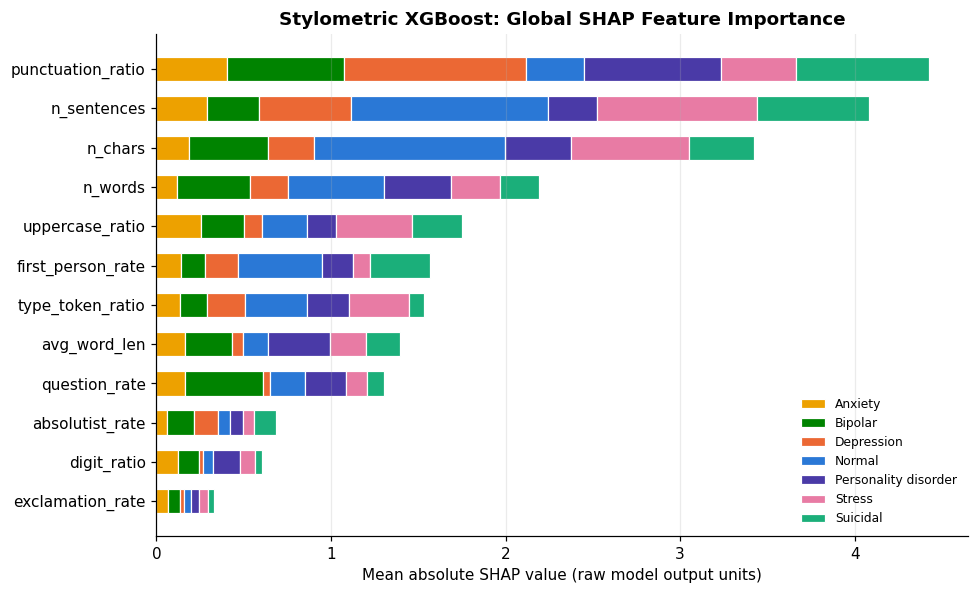

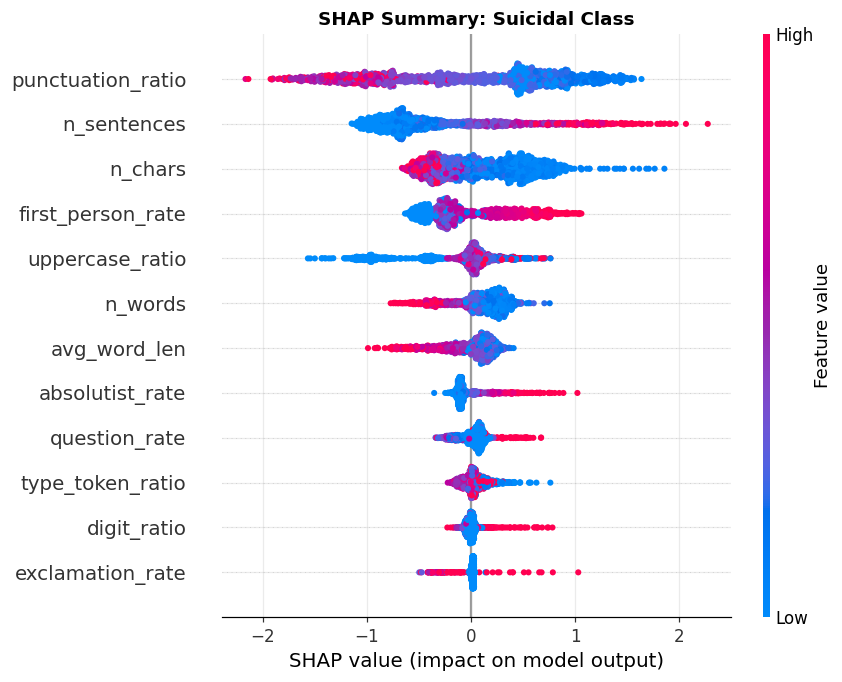

In [26]:
# Global SHAP explanations for the fitted stylometric XGBoost model.
xgb_pipe = ref_models["2 Stylometric + XGBoost"]
clf = xgb_pipe.named_steps["clf"]

if not hasattr(clf, "estimator_"):
    raise AttributeError(
        "The fitted classifier does not expose estimator_. "
        "Inspect clf to identify the underlying fitted XGBoost estimator."
    )

xgb_est = clf.estimator_
xgb_classes = list(clf.classes_)

# Extract stylometric features and preserve the model's feature order.
style_test = stylometric_frame(X_test)
missing_features = set(STYLOMETRIC_FEATURES) - set(style_test.columns)

if missing_features:
    raise ValueError(f"Missing stylometric features: {sorted(missing_features)}")

sample = style_test[STYLOMETRIC_FEATURES].sample(
    n=min(1500, len(style_test)),
    random_state=RANDOM_STATE,
)

# Compute SHAP values.
explainer = shap.TreeExplainer(xgb_est)
shap_output = explainer.shap_values(sample)

# Standardize older list output and newer array output.
if isinstance(shap_output, list):
    sv = np.stack(shap_output, axis=-1)
else:
    sv = np.asarray(shap_output)

expected_shape = (len(sample), len(STYLOMETRIC_FEATURES), len(xgb_classes))

if sv.shape != expected_shape:
    raise ValueError(
        f"Unexpected SHAP output shape: {sv.shape}. "
        f"Expected {expected_shape}. Check the installed SHAP version "
        "and the model's output format."
    )

# Mean absolute SHAP importance for each feature and class.
imp = pd.DataFrame(
    np.abs(sv).mean(axis=0),
    index=STYLOMETRIC_FEATURES,
    columns=xgb_classes,
)

# Keep a consistent label order throughout the project.
imp = imp[[label for label in LABELS if label in imp.columns]]

# Sort features by total importance across classes.
imp = imp.loc[imp.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(9, 5.5))
left = np.zeros(len(imp))

for label in imp.columns:
    ax.barh(
        imp.index,
        imp[label],
        left=left,
        color=COLOR[label],
        label=label,
        height=0.62,
        edgecolor="white",
        linewidth=0.8,
    )
    left += imp[label].to_numpy()

ax.set_xlabel("Mean absolute SHAP value (raw model output units)")
ax.set_title("Stylometric XGBoost: Global SHAP Feature Importance")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, fontsize=8, loc="lower right")

fig.tight_layout()
savefig("shap_stylometric_importance")
plt.show()

# Class-specific SHAP summary.
focus = "Suicidal" if "Suicidal" in xgb_classes else xgb_classes[0]
focus_idx = xgb_classes.index(focus)

shap.summary_plot(
    sv[:, :, focus_idx],
    sample,
    show=False,
    max_display=12,
)

plt.gca().set_title(f"SHAP Summary: {focus} Class")
plt.tight_layout()
savefig("shap_beeswarm_focus_class")
plt.show()

## 12. RQ4: Error Analysis and Robustness Analysis

This section investigates where the final classifier fails, how its errors
relate to prediction confidence, and whether performance varies with input
length.

The dataset contains **no demographic attributes**. Therefore, a fairness
evaluation across demographic or protected groups is not possible, and no
such evaluation is claimed.

The analysis focuses on three questions:

- **Error patterns:** Which classes are most frequently confused, and which
  classes have the weakest recall?
- **Prediction confidence and uncertainty:** Does the model make highly
  confident mistakes, and do conformal prediction sets help identify
  uncertain predictions?
- **Input-length robustness:** Does classification performance change for
  very short, medium-length, and very long posts?

### 12.1 Error Patterns

The final model correctly classified 6,120 of 7,641 test observations,
achieving 80.09% accuracy and a Macro-F1 score of 0.7574.

The most prominent error pattern was confusion between Depression and
Suicidal:

- Depression predicted as Suicidal: 477 cases.
- Suicidal predicted as Depression: 342 cases.

Together, these errors accounted for 819 of the 1,521 misclassifications
(53.8%).

Recall also varied across classes. Normal had the highest recall (93.6%),
whereas Personality disorder had the lowest (62.7%). Depression recall was
70.5%, and Suicidal recall was 74.5%.

These results show that aggregate performance does not fully capture
class-specific weaknesses.

### 12.2 Confident Errors and Conformal Uncertainty

Among misclassified test observations, the mean predicted-class probability
was 0.637 and the median was 0.623. Some errors nevertheless had predicted
probabilities above 0.98.

The true label appeared in the conformal prediction set for 59.4% of
misclassified observations, compared with 99.0% of correctly classified
observations. Mean prediction-set size was 1.859 for errors and 1.313 for
correct predictions.

These findings suggest that prediction-set size provides some information
about model uncertainty, but it does not identify every mistake. In
particular, some incorrect predictions produce singleton sets containing
only the wrong class.

High-confidence errors warrant further investigation. However, confidence
alone does not establish label noise: an error may also arise from ambiguous
language, overlapping class definitions, dataset artifacts, or limitations
of the model.

### 12.3 Input-Length Robustness

Post length may affect classification because very short posts provide
limited textual evidence, whereas long posts may contain multiple themes,
mixed signals, or language associated with more than one dataset label.

To investigate this, the test set will be divided into post-length groups.
Accuracy, Macro-F1, and class-specific recall will be compared across groups.

These results will be interpreted descriptively. Differences between length
groups may reflect changes in class composition as well as changes in model
performance, so class-level results should be examined alongside aggregate
metrics.

### 12.4 Fairness and Scope Limitations

Because demographic attributes are unavailable, this analysis cannot
evaluate differences in model performance across demographic or protected
groups. Post length is a robustness slice, not a substitute for demographic
fairness evaluation.

All results describe model behavior on this dataset. The dataset labels
are not independently verified clinical assessments, and the classifier
is not validated for mental-health diagnosis, screening, or clinical
decision-making.

In [27]:
# RQ4: Robustness by text length and high-confidence errors
# Uses final held-out test predictions only.

y_true = np.asarray(y_test)
y_pred = np.asarray(y_pred_test)
proba = np.asarray(proba_test_cal)

lengths = X_test.str.split().str.len().to_numpy()
conf = proba.max(axis=1)

# Conformal prediction sets from the final test evaluation.
prediction_sets = np.asarray(sets_mond_test, dtype=bool)
set_size = prediction_sets.sum(axis=1)

assert len(lengths) == len(y_true) == len(y_pred) == len(proba)
assert len(set_size) == len(y_true)

# 1. Performance by text-length quintile.
# The cut points are calculated from test-set lengths for descriptive analysis.
bins = pd.qcut(lengths, q=5, duplicates="drop")

slice_rows = []

for b in bins.categories:
    mask = np.asarray(bins == b)
    n = int(mask.sum())

    if n == 0:
        continue

    slice_rows.append({
        "length_bucket_words": str(b),
        "n": n,
        "median_words": float(np.median(lengths[mask])),
        "macro_f1": f1_score(
            y_true[mask],
            y_pred[mask],
            labels=LABELS,
            average="macro",
            zero_division=0,
        ),
        "accuracy": float(np.mean(y_true[mask] == y_pred[mask])),
        "error_rate": float(np.mean(y_true[mask] != y_pred[mask])),
        "mean_90pct_set_size": float(set_size[mask].mean()),
    })

slices = pd.DataFrame(slice_rows)

display(
    slices.style.format({
        "median_words": "{:.1f}",
        "macro_f1": "{:.3f}",
        "accuracy": "{:.3f}",
        "error_rate": "{:.1%}",
        "mean_90pct_set_size": "{:.2f}",
    })
)

# 2. High-confidence errors.
errors = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
    "confidence": conf,
    "words": lengths,
    "set_size": set_size,
    "true_label_in_set": prediction_sets[
        np.arange(len(y_true)),
        np.array([LABELS.index(label) for label in y_true]),
    ],
})

errors = errors.loc[
    errors["true_label"] != errors["predicted_label"]
].copy()

n_errors = len(errors)
n_high_conf = int((errors["confidence"] > 0.90).sum())

print(
    f"Misclassifications: {n_errors:,} of {len(y_true):,} "
    f"({n_errors / len(y_true):.1%})"
)

print(
    f"Errors with predicted-class confidence > 0.90: "
    f"{n_high_conf:,} "
    f"({n_high_conf / n_errors:.1%} of errors)"
    if n_errors
    else "No misclassifications."
)

print(
    "True label included in conformal set for errors: "
    f"{errors['true_label_in_set'].mean():.1%}"
    if n_errors
    else "No misclassifications."
)

print("\nMost frequent error pairs:")
display(
    errors.groupby(["true_label", "predicted_label"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("count")
    .to_frame()
)

,length_bucket_words,n,median_words,macro_f1,accuracy,error_rate,mean_90pct_set_size
0,"(0.999, 12.0]",1628,7.0,0.704,0.956,4.4%,1.05
1,"(12.0, 36.0]",1458,21.0,0.725,0.822,17.8%,1.26
2,"(36.0, 85.0]",1499,61.0,0.690,0.724,27.6%,1.60
3,"(85.0, 176.0]",1534,120.0,0.660,0.723,27.7%,1.59
4,"(176.0, 2319.0]",1522,279.0,0.648,0.769,23.1%,1.63


Misclassifications: 1,521 of 7,641 (19.9%)
Errors with predicted-class confidence > 0.90: 140 (9.2% of errors)
True label included in conformal set for errors: 59.4%

Most frequent error pairs:


count
true_label predicted_label            
Depression Suicidal                477
Suicidal   Depression              342
Normal     Stress                   95
Depression Normal                   63
Suicidal   Normal                   55
Stress     Anxiety                  41
Depression Stress                   40
           Bipolar                  33
           Anxiety                  30
           Personality disorder     24

### Input-Length Robustness

The test set was divided into five approximately equal-sized groups based
on the number of words in each post. Each group contained between 1,458
and 1,628 observations. Performance was evaluated using accuracy, Macro-F1,
error rate, and mean class-conditional conformal prediction-set size.

| Length group | Median words | Accuracy | Macro-F1 | Error rate | Mean set size |
|---|---:|---:|---:|---:|---:|
| Very short (≤12 words) | 7 | 0.956 | 0.704 | 4.4% | 1.05 |
| Short (13–36 words) | 21 | 0.822 | 0.725 | 17.8% | 1.26 |
| Medium (37–85 words) | 61 | 0.724 | 0.690 | 27.6% | 1.60 |
| Long (86–176 words) | 120 | 0.723 | 0.660 | 27.7% | 1.59 |
| Very long (>176 words) | 279 | 0.769 | 0.648 | 23.1% | 1.63 |

**Main observations:**

- **Accuracy was highest for very short posts**, at 95.6%, and lowest for
  the medium-length group, at 72.4%.
- **Macro-F1 was highest for short posts**, at 0.725, and lowest for very
  long posts, at 0.648. The difference between accuracy and Macro-F1 in the
  shortest group indicates that performance was less balanced across classes
  than its accuracy alone suggests.
- **Error rates increased substantially with length** from the shortest
  group to the medium-length groups, rising from 4.4% to approximately
  27.7%. The very-long group had a lower error rate of 23.1%, so the
  relationship is not strictly monotonic.
- **Mean conformal prediction-set size increased with length**, from 1.05
  for very short posts to 1.63 for very long posts. This suggests that the
  model generally returned less compact prediction sets for longer text.

These results indicate that post length is associated with differences in
classification performance and prediction-set size. However, they do not
establish that length itself causes the performance differences. Longer
posts may contain more mixed themes, conflicting linguistic signals, or
different proportions of the dataset's classes.

The exceptionally high accuracy for very short posts should also be
investigated rather than assumed to reflect an inherent advantage of short
text. Class composition, recurring phrases, and dataset-specific patterns
could contribute to this result.

Further analysis should compare class distributions and per-class recall
across length groups. This would help determine whether the observed pattern
reflects changes in class composition, class-specific model weaknesses, or
both.

### 12.1 How Noisy Are the Labels? Confident Learning

Some classification errors may reflect incorrect or ambiguous dataset labels
rather than limitations of the model. Confident learning (Northcutt et al.,
2021) provides a systematic way to identify potentially mislabeled examples.

The analysis follows three steps:

1. **Out-of-fold predictions:** Generate predictions for training observations
   using models that were not trained on the corresponding observations.
   This reduces the optimism that would arise from evaluating a model on
   examples it has already seen.
2. **Class-specific confidence thresholds:** Estimate thresholds from the
   out-of-fold predicted probabilities for each class.
3. **Confident joint:** Count examples whose observed labels and predicted
   classes satisfy the confidence-threshold criteria. The resulting matrix
   estimates the distribution of potential label issues between class pairs.

Examples flagged by this procedure are **candidates for manual review, not
confirmed label errors**. Disagreement between a model prediction and an
observed label may also arise from ambiguous text, overlapping class
definitions, insufficient information, or model limitations.

#### Experimental protocol

The confident-learning analysis is conducted on the training split using
out-of-fold predictions. The calibration and test splits are not used to
identify candidate label errors.

The primary model and its reported test results remain unchanged. A separate
pruning experiment may remove selected candidate examples from the training
data to investigate sensitivity to potential label noise. This experiment
is exploratory and is not used to replace the primary model or select a
model based on test-set performance.

Because the dataset labels are not independently verified clinical
assessments, the estimated noise matrix should be interpreted as a model-based
diagnostic rather than definitive evidence of incorrect labels.

Candidate label issues: 3,103 of 35,657 training posts (8.7%)


,estimated noise rate
given,
Anxiety,7.5%
Bipolar,9.7%
Depression,21.2%
Normal,3.5%
Personality disorder,15.4%
Stress,11.8%
Suicidal,18.5%


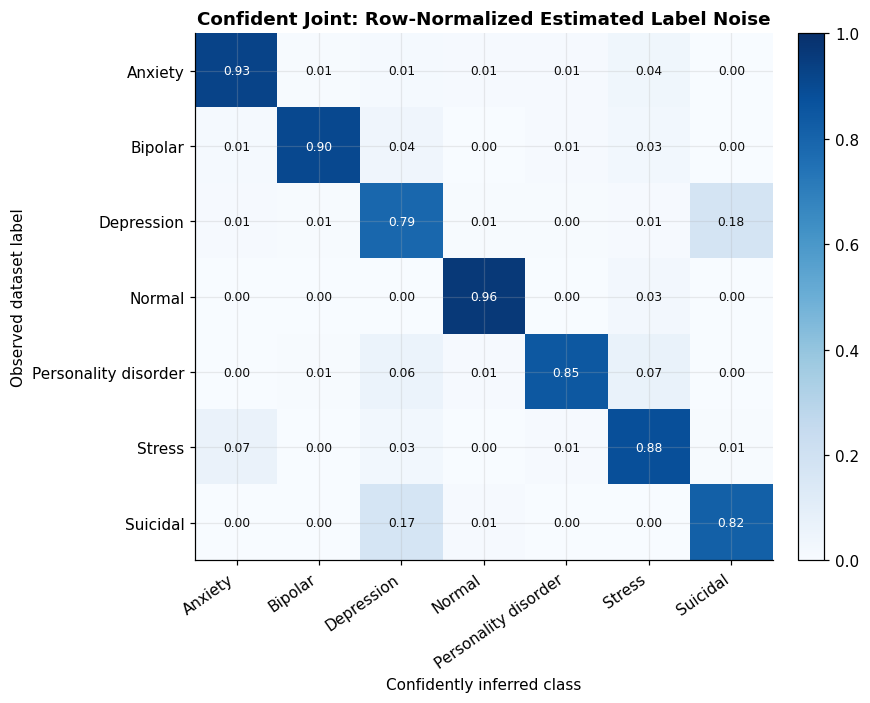

,training_posts,test_macro_f1
Final model: all training posts,"35,657",0.7574
Sensitivity model: flagged posts removed,"32,554",0.7570


Macro-F1 change after filtering: -0.0005


In [28]:
# RQ4: Confident-learning label-noise investigation

# 1. Generate out-of-fold probabilities on the training split.
# The TF-IDF vectorizer must be inside this pipeline so each fold
# learns its vocabulary and IDF weights only from its fold-training data.

noise_probe = model_ladder(
    RANDOM_STATE,
    include_xgb=False,
)["4 Word TF-IDF + LogReg"]

cv_noise = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

proba_oof = cross_val_predict(
    noise_probe,
    X_train,
    y_train,
    method="predict_proba",
    cv=cv_noise,
    n_jobs=2,
)

assert len(proba_oof) == len(y_train), (
    "OOF predictions and training labels have different lengths."
)

# Cross-validation probabilities follow the estimator's class order.
# For this Logistic Regression classifier, verify that this matches LABELS.
oof_classes = sorted(pd.Series(y_train).unique().tolist())

if oof_classes != list(LABELS):
    raise ValueError(
        "OOF probability class order does not match LABELS. "
        f"OOF order: {oof_classes}; LABELS: {list(LABELS)}"
    )

assert proba_oof.shape == (len(y_train), len(LABELS))

# 2. Identify candidate label issues.
# Assumes find_label_issues is the notebook's existing helper.
issues, joint = find_label_issues(proba_oof, y_train, LABELS)

if "is_issue" not in issues.columns:
    raise ValueError("The issues table must contain an 'is_issue' column.")

if len(issues) != len(X_train):
    raise ValueError(
        "The issue table must contain one row per training observation."
    )

# Preserve positional alignment with X_train and y_train.
issue_mask = issues["is_issue"].to_numpy(dtype=bool)
keep = ~issue_mask

n_flagged = int(issue_mask.sum())

print(
    f"Candidate label issues: {n_flagged:,} of {len(X_train):,} "
    f"training posts ({issue_mask.mean():.1%})"
)

# Estimated noise rates by observed class.
noise_rates = estimated_noise_rate(joint).reindex(LABELS)

display(
    noise_rates.rename("estimated noise rate")
    .to_frame()
    .style.format("{:.1%}")
)

# 3. Visualize the row-normalized confident joint.
# Rows represent observed/given labels; columns follow the helper's
# confidently inferred class convention.

J = joint.reindex(
    index=LABELS,
    columns=LABELS,
    fill_value=0,
)

row_sums = J.sum(axis=1).replace(0, np.nan)
Jn = J.div(row_sums, axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(8, 6.5))

im = ax.imshow(
    Jn.to_numpy(),
    cmap="Blues",
    vmin=0,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(
    range(len(LABELS)),
    LABELS,
    rotation=35,
    ha="right",
)
ax.set_yticks(range(len(LABELS)), LABELS)

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        value = Jn.iat[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if value > 0.55 else "#0b0b0b",
        )

ax.set_xlabel("Confidently inferred class")
ax.set_ylabel("Observed dataset label")
ax.set_title("Confident Joint: Row-Normalized Estimated Label Noise")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

savefig("label_noise_confident_joint")
plt.show()

# 4. Sensitivity experiment: refit the same model configuration
# after removing flagged training observations.
# This is an exploratory comparison, not the replacement final model.

X_train_pruned = X_train.iloc[np.flatnonzero(keep)]
y_train_pruned = y_train.iloc[np.flatnonzero(keep)]

pruned_model = clone(final_model)
pruned_model.fit(X_train_pruned, y_train_pruned)

y_test_array = np.asarray(y_test)
y_pred_pruned = pruned_model.predict(X_test)

baseline_f1 = f1_score(
    y_test_array,
    y_pred_test,
    labels=LABELS,
    average="macro",
    zero_division=0,
)

pruned_f1 = f1_score(
    y_test_array,
    y_pred_pruned,
    labels=LABELS,
    average="macro",
    zero_division=0,
)

noise_table = pd.DataFrame(
    {
        "training_posts": [
            len(X_train),
            len(X_train_pruned),
        ],
        "test_macro_f1": [
            baseline_f1,
            pruned_f1,
        ],
    },
    index=[
        "Final model: all training posts",
        "Sensitivity model: flagged posts removed",
    ],
)

display(
    noise_table.style.format({
        "training_posts": "{:,}",
        "test_macro_f1": "{:.4f}",
    })
)

print(f"Macro-F1 change after filtering: {pruned_f1 - baseline_f1:+.4f}")

### Confident Learning: Investigating Potential Label Noise

Confident learning was used to investigate potential inconsistencies between
the observed dataset labels and patterns learned by a text classifier.
Out-of-fold predictions were generated for the training split so that each
observation was evaluated by a model that had not trained on it.

The procedure flagged **3,103 of 35,657 training posts (8.7%)** as candidate
label issues. Estimated rates varied by observed class:

| Observed label | Estimated noise rate |
|---|---:|
| Anxiety | 7.5% |
| Bipolar | 9.7% |
| Depression | 21.2% |
| Normal | 3.5% |
| Personality disorder | 15.4% |
| Stress | 11.8% |
| Suicidal | 18.5% |

Depression had the highest estimated rate (21.2%), followed by Suicidal
(18.5%) and Personality disorder (15.4%). Normal had the lowest estimated
rate (3.5%).

These figures are model-based estimates, not verified label-error rates.
Higher estimates may reflect ambiguous text, overlapping class definitions,
class-specific model limitations, or genuine annotation inconsistencies.
Without independent label verification, the flagged examples cannot be
assumed to be incorrectly labeled.

#### Sensitivity experiment

To examine sensitivity to the flagged observations, the same model
configuration was retrained after removing all 3,103 candidates.

| Experiment | Training posts | Test Macro-F1 |
|---|---:|---:|
| Original training set | 35,657 | 0.7574 |
| Candidate issues removed | 32,554 | 0.7570 |
| Change | -3,103 | -0.0005 |

Removing the flagged observations did not improve test Macro-F1. The score
decreased by approximately 0.0005, a negligible difference in practical
terms.

This result does not establish that the flagged labels are correct or
incorrect. It indicates that removing the candidates identified by this
particular procedure did not produce a meaningful improvement in the
reported test Macro-F1.

#### Conclusion

The confident-learning analysis identified a subset of training observations
for potential review, but the pruning experiment provided no evidence of a
performance benefit from removing them.

The original model is therefore retained as the primary model. The
confident-learning results are reported as a diagnostic and sensitivity
analysis, not as proof of label noise or evidence that automated pruning
improves model quality.

## 13. RQ5: Unsupervised Structure (Topics Without Labels)

Does the language in the dataset organize itself into stable clusters before
the existing labels are considered?

This experiment investigates whether the text contains reproducible
structure without using the dataset's class labels to fit or select the
clusters.

### Pipeline

1. **Word-level TF-IDF:** Represent each post using weighted word unigrams
   and bigrams.
2. **Latent Semantic Analysis (LSA):** Apply truncated SVD to reduce the
   sparse TF-IDF representation to 100 dimensions.
3. **L2 normalization:** Normalize the reduced vectors to unit length so
   their directions, rather than their magnitudes, determine similarity.
4. **K-means clustering:** Cluster the normalized representations using
   Euclidean distance. For unit-normalized vectors, squared Euclidean
   distance is directly related to cosine distance, making this a practical
   approximation to cosine-oriented clustering.

### Selecting the Number of Clusters

The number of clusters, *k*, is selected using internal clustering criteria,
without consulting the existing dataset labels:

- **Silhouette score:** Measures how well-separated clusters are relative
  to their internal cohesion. Higher values generally indicate better
  separation.
- **Clustering stability:** Measures agreement between cluster assignments
  obtained from different K-means initializations using the Adjusted Rand
  Index (ARI). Higher agreement indicates more reproducible assignments.

These criteria assess different properties. A clustering can be stable
without being well separated, and a high silhouette score does not establish
that the clusters represent meaningful topics.

After selecting *k*, the cluster assignments are compared with the existing
dataset labels using Normalized Mutual Information (NMI) and ARI. These
external metrics are used only for post-selection evaluation and do not
influence the choice of *k*.

### Interpretation and Limitations

The resulting clusters may reflect recurring themes, vocabulary, writing
style, post length, or dataset-specific artifacts. They should not
automatically be interpreted as psychological categories or as evidence
that the dataset labels correspond to distinct natural groups.

The experiment evaluates the structure captured by this particular
TF-IDF, LSA, and K-means pipeline. Its findings do not establish that the
same structure would emerge with other representations or clustering
algorithms.

In [29]:
# RQ5: Unsupervised clustering with TF-IDF + LSA + K-means
# No labels are used to sample data, fit clusters, or select k.

# 1. Draw an unstratified sample from training text.
if len(X_train) > CLUSTER_SAMPLE:
    Xc = train_test_split(
        X_train,
        train_size=CLUSTER_SAMPLE,
        random_state=RANDOM_STATE,
    )[0]
else:
    Xc = X_train.copy()

# 2. Word-level TF-IDF.
vec_c = TfidfVectorizer(
    min_df=3,
    max_df=0.5,
    stop_words="english",
    sublinear_tf=True,
    max_features=30_000,
)

Tc = vec_c.fit_transform(Xc)

if Tc.shape[1] < 2:
    raise ValueError(
        f"Insufficient TF-IDF features for LSA: {Tc.shape[1]}"
    )

# 3. LSA dimensionality reduction.
n_components = min(100, Tc.shape[1] - 1)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=RANDOM_STATE,
)

Z = svd.fit_transform(Tc)

# 4. L2-normalize the LSA representations.
Z = Normalizer(copy=False).fit_transform(Z)

print(
    f"LSA on {len(Xc):,} posts | "
    f"{svd.n_components} components explain approximately "
    f"{svd.explained_variance_ratio_.sum():.1%} of variance"
)

# 5. Evaluate candidate cluster counts using internal criteria.
k_rows = []
labelings = {}

for k in range(3, 11):
    runs = [
        KMeans(
            n_clusters=k,
            n_init=5,
            random_state=RANDOM_STATE + seed,
        ).fit_predict(Z)
        for seed in range(5)
    ]

    # Retain one valid clustering for post-selection evaluation.
    labelings[k] = runs[0]

    # ARI is invariant to arbitrary cluster ID permutations.
    stability_ari = np.mean([
        adjusted_rand_score(runs[0], run)
        for run in runs[1:]
    ])

    silhouette = silhouette_score(
        Z,
        runs[0],
        metric="euclidean",
        sample_size=min(5_000, len(Z)),
        random_state=RANDOM_STATE,
    )

    k_rows.append({
        "k": k,
        "silhouette": silhouette,
        "stability_ARI": stability_ari,
    })

k_table = pd.DataFrame(k_rows).set_index("k")

# Equal-weight rank aggregation of the two internal criteria.
# Higher silhouette and higher stability receive better ranks.
k_table["selection_score"] = (
    k_table["silhouette"].rank(pct=True)
    + k_table["stability_ARI"].rank(pct=True)
)

BEST_K = int(k_table["selection_score"].idxmax())

display(
    k_table.style.format({
        "silhouette": "{:.3f}",
        "stability_ARI": "{:.3f}",
        "selection_score": "{:.3f}",
    })
)

print(f"Selected k = {BEST_K} (internal criteria only)")

# Labels are aligned only AFTER k has been selected.
yc = y_train.loc[Xc.index]

LSA on 15,000 posts | 100 components explain approximately 17.0% of variance


,silhouette,stability_ARI,selection_score
k,,,
3,0.014,0.985,1.000
4,0.016,0.993,1.250
5,0.020,0.914,1.500
6,0.018,0.801,1.000
7,0.020,0.502,0.750
8,0.018,0.766,1.000
9,0.022,0.740,1.250
10,0.026,0.572,1.250


Selected k = 5 (internal criteria only)


### Selecting the Number of Clusters

The clustering pipeline was fitted to an unstratified sample of 15,000
training posts. Word-level TF-IDF representations were reduced to 100
LSA dimensions, which explained approximately 17.0% of the variance.
The normalized representations were then clustered using K-means.

Candidate values of *k* from 3 to 10 were evaluated using silhouette score
and stability across five K-means runs with different random seeds.
The selection score was the sum of the percentile ranks of these two
internal criteria.

The procedure selected **k = 5**.

The results show a trade-off between separation and stability:

- **k = 5** achieved a silhouette score of 0.020 and a stability ARI of
  0.914.
- **k = 4** achieved a silhouette score of 0.016 and the highest stability
  ARI, at 0.993.
- **k = 10** achieved the highest silhouette score, at 0.026, but had a
  lower stability ARI of 0.572.

The silhouette scores were low across all candidate values, indicating
weak separation between clusters in the evaluated representation. The
stability results also declined for several larger values of *k*.

Therefore, *k = 5* is the selected candidate under the predefined
rank-aggregation rule, not evidence that the dataset contains exactly
five naturally distinct topics. The selected solution should be examined
further using cluster sizes, representative terms, and post-selection
agreement with the existing labels.

In [30]:
# Use the cluster assignments from the selected unsupervised solution
clusters = np.asarray(labelings[BEST_K])

assert len(clusters) == len(Z) == len(yc), (
    "Cluster assignments, embeddings, and labels must have matching lengths."
)

# Calculate centroids directly from the embeddings assigned to each cluster
centroids_z = np.vstack([
    Z[clusters == c].mean(axis=0)
    for c in range(BEST_K)
])

# Project centroids back into the TF-IDF feature space for term interpretation
centroids = svd.inverse_transform(centroids_z)
terms = vec_c.get_feature_names_out()

cluster_terms = pd.DataFrame({
    f"Cluster {c}": terms[np.argsort(centroids[c])[::-1][:10]]
    for c in range(BEST_K)
})

display(cluster_terms)

# Compare the selected clusters with the dataset's existing labels.
# Labels are used only for post-selection evaluation, not to choose BEST_K.
print(
    f"Agreement with labels — "
    f"NMI: {normalized_mutual_info_score(yc, clusters):.3f} | "
    f"ARI: {adjusted_rand_score(yc, clusters):.3f}"
)

ct = pd.crosstab(
    pd.Series(clusters, name="Cluster"),
    pd.Series(yc.to_numpy(), name="Label"),
    normalize="index"
)

ct = ct[[label for label in labels_present if label in ct.columns]]

display(ct.style.format("{:.1%}").background_gradient(cmap="Blues", axis=None))

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
0,don,depression,ve,just,want
1,really,http,anxiety,like,just
2,day,anxiety,don,feel,die
3,just,like,just,life,kill
4,today,just,like,know,life
5,like,help,know,people,anymore
6,time,depressed,feel,want,like
7,going,theekween,time,time,know
8,good,feel,really,really,feel
9,got,thelmasherbs,having,think,fucking


Agreement with labels — NMI: 0.263 | ARI: 0.286


Label,Normal,Depression,Suicidal,Anxiety,Stress,Bipolar,Personality disorder
Cluster,,,,,,,
0,68.3%,9.8%,12.3%,4.2%,3.3%,1.4%,0.7%
1,1.7%,88.6%,3.9%,0.7%,1.5%,3.2%,0.4%
2,10.0%,20.8%,1.7%,32.9%,11.1%,20.5%,3.0%
3,2.9%,50.5%,34.9%,1.2%,4.1%,3.1%,3.3%
4,20.3%,28.6%,46.0%,0.9%,1.8%,1.8%,0.6%


### Findings and Limitations

The five-cluster solution revealed several interpretable patterns in the text. Cluster 1 was strongly associated with Depression (88.6%), while Cluster 0 was predominantly Normal (68.3%). Clusters 3 and 4 contained substantial overlap between Depression and Suicidal labels, while Cluster 2 combined Anxiety, Depression, Bipolar, and Stress.

Agreement with the existing labels was limited (NMI = 0.263; ARI = 0.286). The silhouette score was also low (0.020), indicating weak cluster separation under the evaluated representation and distance metric. These results suggest that the text contains some label-associated structure, but shared vocabulary prevents the unsupervised method from cleanly separating all seven categories.

The top terms provide clues about each cluster's language patterns, but generic words and potential dataset artifacts, including URLs or unusual tokens, may limit their interpretability. Representative posts should be inspected before assigning descriptive names to the clusters.

**Limitations:**
- The five-cluster solution was selected using internal silhouette and stability criteria, not agreement with the existing labels.
- The 100-component LSA representation explained approximately 17% of the variance, so some information from the original TF-IDF representation was not retained.
- The low silhouette score suggests that the clusters are not strongly separated.
- The existing labels were used only for post-selection evaluation; they did not determine the clustering solution.
- Cluster membership reflects patterns in the text and must not be interpreted as a clinical classification or evidence of distinct psychological groups.

**Conclusion:** The clustering experiment identified some label-associated textual patterns, particularly for Normal and Depression posts, but showed limited overall alignment with the seven existing labels. Further inspection of representative posts and potential text artifacts is warranted before attempting alternative preprocessing or clustering methods.

## 14. Artefacts, model card and inference API

In [31]:
## 14. Artefacts, model card and inference API

# Package the trained model and inference components
smm_model = SocialMediaMindModel(
    pipeline=final_model,
    temperature=ts.temperature_,
    conformal=cp_mond,
    labels=[str(label) for label in LABELS],
    metadata={
        "family": FINAL_FAMILY,
        "best_params": BEST_PARAMS,
        "test_macro_f1": float(point),
        "environment": ENV,
    },
)

# Save the model bundle
bundle_path = smm_model.save(MODEL_DIR / "socialmediamind_bundle.joblib")
print(f"Model bundle saved to: {bundle_path}")

# Reload the saved bundle and verify that it can make predictions
reloaded = SocialMediaMindModel.load(bundle_path)

example_texts = [
    "Had a great time hiking with friends this weekend!",
    "I can't stop worrying about everything, my heart keeps racing at night.",
]

predictions = reloaded.predict(example_texts)
display(predictions)

# Basic persistence and inference checks
assert reloaded.labels == smm_model.labels, "Labels changed after reloading."
assert len(predictions) == len(example_texts), "Unexpected number of predictions."

print("Model bundle round-trip and inference checks passed.")

Model bundle saved to: /content/models/socialmediamind_bundle.joblib


[{'top_label': 'Normal',
  'confidence': 0.967,
  'prediction_set': ['Normal'],
  'defer_to_human': False},
 {'top_label': 'Anxiety',
  'confidence': 0.9058,
  'prediction_set': ['Anxiety'],
  'defer_to_human': False}]

Model bundle round-trip and inference checks passed.


In [35]:
# Recompute test performance after removing suspected label issues
from sklearn.base import clone
from sklearn.metrics import f1_score

keep = ~issues["is_issue"].to_numpy()

pruned_model = clone(final_model).fit(
    X_train[keep],
    y_train[keep],
)

f1_pruned = f1_score(
    y_test,
    pruned_model.predict(X_test),
    average="macro",
)

print(f"Original model test Macro-F1: {point:.4f}")
print(f"Pruned model test Macro-F1:   {f1_pruned:.4f}")
print(f"Change:                       {f1_pruned - point:+.4f}")

Original model test Macro-F1: 0.7574
Pruned model test Macro-F1:   0.7570
Change:                       -0.0005


- **Label-issue analysis:** Confident learning flagged 8.7% of training
  posts as potential label issues. The highest estimated class-level
  noise rate was for Depression (21.2%). These are model-based estimates,
  not confirmed annotation errors.
- **Pruning experiment:** Removing flagged training examples changed
  test Macro-F1 from 0.7574 to 0.7570 (Δ = -0.0005). Pruning did not
  improve performance, so the original model was retained.

In [36]:
# Reproducibility, Metrics Export and Model Card

import json
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# 1. JSON-safe conversion
# ---------------------------------------------------------------------
def json_safe(value):
    """Convert common NumPy and pandas values into valid JSON-compatible values."""
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}

    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]

    if isinstance(value, np.ndarray):
        return json_safe(value.tolist())

    if isinstance(value, np.generic):
        return json_safe(value.item())

    if value is None:
        return None

    if isinstance(value, (float, int)) and not isinstance(value, bool):
        return value if np.isfinite(value) else None

    if pd.isna(value):
        return None

    return value


# ---------------------------------------------------------------------
# 2. Export experiment metrics
# ---------------------------------------------------------------------
metrics = {
    "dataset": {
        "source": "kaggle:suchintikasarkar/sentiment-analysis-for-mental-health",
        "cleaning": cleaning.to_dict(),
        "splits": splits.sizes(),
    },

    "leakage_demo": {
        "naive_macro_f1": float(f1_naive),
        "dedup_macro_f1": float(f1_clean),
        "naive_test_dup_share": float(leaked),
    },

    "cv_model_ladder": cv_table.round(4).to_dict(orient="index"),

    "best_params": {
        k: list(v) if isinstance(v, tuple)
        else float(v) if isinstance(v, (float, np.floating))
        else v
        for k, v in BEST_PARAMS.items()
    },

    "test": {
        **test_table.loc[FINAL_NAME].dropna().to_dict(),
        "macro_f1_ci95": [float(lo), float(hi)],
    },

    "calibration": {
        "temperature": float(ts.temperature_),
        **calib["temperature-scaled"].to_dict(),
    },

    "conformal": {
        "alpha": float(ALPHA),
        "mondrian_overall_coverage": float(
            cov_mond.loc["ALL", "coverage"]
        ),
        "mondrian_mean_set_size": float(
            cov_mond.loc["ALL", "mean_set_size"]
        ),
        "min_class_coverage_marginal": float(
            cov_marg.drop("ALL")["coverage"].min()
        ),
        "min_class_coverage_mondrian": float(
            cov_mond.drop("ALL")["coverage"].min()
        ),
    },

    "conformal_methods": set_methods.round(4).to_dict(orient="index"),

    "label_noise": {
        "flagged_share": float(issues["is_issue"].mean()),
        "noise_rate_by_class": noise_rates.round(4).to_dict(),
        "test_macro_f1_pruned": float(f1_pruned),
    },

    "transformer": transformer_summary,

    "clustering": {
        "k": int(BEST_K),
        "nmi_vs_labels": float(
            normalized_mutual_info_score(yc, clusters)
        ),
        "ari_vs_labels": float(
            adjusted_rand_score(yc, clusters)
        ),
    },

    "environment": ENV,
}

metrics_path = REPORT_DIR / "metrics.json"
metrics_path.write_text(
    json.dumps(json_safe(metrics), indent=2, allow_nan=False),
    encoding="utf-8",
)

print(f"Metrics exported: {metrics_path.relative_to(ROOT)}")


# ---------------------------------------------------------------------
# 3. Build per-class performance table
# ---------------------------------------------------------------------
per_class = report.loc[
    [c for c in labels_present if c in report.index],
    ["precision", "recall", "f1-score", "support"],
]

per_class_md = (
    "| Class | Precision | Recall | F1 | Support |\n"
    "|---|---:|---:|---:|---:|\n"
    + "\n".join(
        f"| {c} | {r['precision']:.3f} | {r['recall']:.3f} | "
        f"{r['f1-score']:.3f} | {int(r['support']):,} |"
        for c, r in per_class.iterrows()
    )
)


# ---------------------------------------------------------------------
# 4. Prepare final model performance values
# ---------------------------------------------------------------------
final_metrics = test_table.loc[FINAL_NAME]

test_macro_f1 = float(point)
test_balanced_accuracy = float(final_metrics["balanced_accuracy"])
test_accuracy = float(final_metrics["accuracy"])

ece_after = float(calib.loc["ece", "temperature-scaled"])
ece_before = float(calib.loc["ece", "uncalibrated"])

mondrian_coverage = float(cov_mond.loc["ALL", "coverage"])
mondrian_mean_size = float(cov_mond.loc["ALL", "mean_set_size"])
mondrian_min_class_coverage = float(
    cov_mond.drop("ALL")["coverage"].min()
)

flagged_share = float(issues["is_issue"].mean())
highest_noise_class = noise_rates.idxmax()
highest_noise_rate = float(noise_rates.max())

# Use the model's recorded family name rather than relying on string slicing.
model_family = str(FINAL_FAMILY)


# ---------------------------------------------------------------------
# 5. Generate model card
# ---------------------------------------------------------------------
if transformer_summary is None:
    transformer_text = (
        "Not evaluated. No transformer performance result is reported."
    )
else:
    transformer_text = (
        f'{TRANSFORMER_NAME} macro-F1 '
        f'{transformer_summary["test_macro_f1"]:.3f}, '
        f'Δ vs. linear model '
        f'{transformer_summary["delta_macro_f1"]:+.3f} '
        f'(95% CI '
        f'{transformer_summary["delta_ci95"][0]:+.3f} to '
        f'{transformer_summary["delta_ci95"][1]:+.3f}).'
    )


card = f"""# Model Card: SocialMediaMind Text Classifier

*Auto-generated by `notebooks/SocialMediaMind.ipynb` on
{smm_model.metadata["saved_utc"]}.*

## Model

**Model family:** {model_family}

**Classifier:** Class-balanced multinomial logistic regression.

**Probability calibration:** Temperature scaling, T = {ts.temperature_:.3f}.

**Uncertainty estimation:** Class-conditional split-conformal prediction
sets at nominal target coverage of {1 - ALPHA:.0%}.

**Selected hyperparameters:** `{BEST_PARAMS}`.

## Intended Use

This model is intended for research, teaching, and portfolio demonstration
of text classification and trustworthy-ML techniques.

**Out of scope:** Clinical diagnosis, mental-health screening, triage of
real people, content moderation decisions, or decisions affecting an
individual.

The predictions represent dataset-specific text labels. They are not
clinical assessments of the authors.

## Data

**Source:** Kaggle
`suchintikasarkar/sentiment-analysis-for-mental-health`.

The dataset contains public social-media text and source-provided labels.
These labels should not be assumed to represent clinically verified
conditions.

After cleaning, the dataset contained **{cleaning.n_final:,} unique posts**.
Cleaning removed {cleaning.n_exact_duplicates_removed:,} exact duplicates
and {cleaning.n_conflicting_rows_removed:,} rows associated with
conflicting labels.

**Data splits:** `{splits.sizes()}`.

## Performance on the Held-Out Test Set

**Evaluated model:** {FINAL_NAME}

**Test sample size:** {len(y_test):,}

- **Macro-F1:** {test_macro_f1:.3f}
  (95% bootstrap confidence interval: {lo:.3f}–{hi:.3f})
- **Balanced accuracy:** {test_balanced_accuracy:.3f}
- **Accuracy:** {test_accuracy:.3f}
- **ECE after temperature scaling:** {ece_after:.3f}
  (before calibration: {ece_before:.3f})
- **Observed Mondrian conformal coverage:** {mondrian_coverage:.3f}
- **Mean conformal set size:** {mondrian_mean_size:.2f}
- **Lowest observed class-level conformal coverage:**
  {mondrian_min_class_coverage:.3f}

### Per-Class Performance

{per_class_md}

## Additional Analyses

- **Label-issue analysis:** Confident learning flagged
  {flagged_share:.1%} of training posts as potential label issues.
  The highest estimated class-level noise rate was for
  **{highest_noise_class}** ({highest_noise_rate:.1%}).
  These are model-based estimates, not confirmed annotation errors.
- **Pruning experiment:** Test macro-F1 after pruning flagged training
  examples was {f1_pruned:.3f}. This experiment did not establish that
  removing flagged examples improves performance.
- **Transformer baseline:** {transformer_text}
- **Unsupervised clustering:** The selected solution used {BEST_K}
  clusters. Agreement with existing labels was
  NMI = {normalized_mutual_info_score(yc, clusters):.3f} and
  ARI = {adjusted_rand_score(yc, clusters):.3f}. These are exploratory
  clustering results, not classification performance metrics.

## Usage

The serialized model bundle is saved as
`models/socialmediamind_bundle.joblib`.

Inference is available through the `SocialMediaMindModel` Python
interface. A command-line interface should be documented here only
after the corresponding command has been implemented and tested.

## Limitations and Risks

- **No clinical validity:** The labels are noisy proxies derived from
  the source dataset and are not clinically verified diagnoses.
- **Dataset artifacts:** The model may learn writing style, text length,
  platform artifacts, or other spurious correlations.
- **Class imbalance:** Performance differs across categories; aggregate
  metrics can obscure weaker performance for individual classes.
- **Fairness:** Demographic information was unavailable or not evaluated,
  so fairness across demographic groups remains unassessed.
- **Distribution shift:** The data represent a particular dataset and
  collection period. Performance may degrade on new platforms,
  populations, or time periods.
- **Conformal assumptions:** Observed coverage does not guarantee future
  coverage under distribution shift. The usual statistical guarantees
  depend on assumptions such as exchangeability between calibration
  and future observations.
- **Safety:** False negatives on crisis-related content are possible.
  This model must not be used as the sole safeguard for identifying or
  responding to people in crisis.
- **Privacy:** Avoid exposing raw social-media posts or sensitive
  examples in public reports and demonstrations.
- **Serialization security:** Only load the `joblib` bundle from a
  trusted source because deserialization can execute arbitrary code.

## Reproducibility

The accompanying `metrics.json` records key experimental results,
model-selection parameters, calibration and conformal metrics,
clustering results, and environment metadata.

Results should be interpreted in the context of the stated dataset,
preprocessing pipeline, data splits, and evaluation methodology.
"""


# ---------------------------------------------------------------------
# 6. Save model card and report generated artefacts
# ---------------------------------------------------------------------
card_path = REPORT_DIR / "MODEL_CARD.md"

card_path.write_text(card, encoding="utf-8")

generated_files = sorted(
    p.relative_to(ROOT).as_posix()
    for p in (
        list(REPORT_DIR.glob("*.*"))
        + list(MODEL_DIR.glob("*.*"))
    )
    if p.is_file()
)

print("\nGenerated artefacts:")
for path in generated_files:
    print(f"  {path}")

print("\nMetrics JSON and model card saved successfully.")

Metrics exported: reports/metrics.json

Generated artefacts:
  models/socialmediamind_bundle.joblib
  reports/MODEL_CARD.md
  reports/conformal_coverage.csv
  reports/conformal_methods.csv
  reports/cv_model_ladder.csv
  reports/metrics.json
  reports/top_terms_per_class.csv

Metrics JSON and model card saved successfully.


## 15. Summary, Limitations and Next Steps

The final cell prints the headline results. The complete experimental record is saved in
`reports/metrics.json` and `reports/MODEL_CARD.md`.

### What the Evidence Supports

- **RQ1: Stylometric analysis.** Interpretable stylometric features differ across dataset categories, with measurable effect sizes. These features carry predictive signal, but the model ladder shows that style alone performs substantially worse than text-based representations.

- **RQ2: Text classification and leakage.** Word and character n-grams substantially improve predictive performance over stylometric features alone. The evaluation controls for duplicate-text leakage, and Section 4.1 demonstrates how retaining duplicates can inflate measured performance.

- **RQ3: Calibration and uncertainty.** Temperature scaling improved the measured calibration metrics on the calibration evaluation split without changing the predicted classes. Class-conditional split-conformal prediction produced more balanced empirical coverage across classes than marginal conformal prediction, although prediction sets were larger on average. These findings depend on the calibration procedure and its statistical assumptions; they do not establish guaranteed performance under distribution shift.

- **RQ4: Error analysis and model explanations.** Errors are concentrated in particular label pairs, especially Depression/Suicidal, with additional confusion between other categories. Local explanations illustrate which text features influence individual model predictions. These patterns describe model behavior, not clinical equivalence between labels.

- **RQ5: Unsupervised structure.** Clustering revealed some label-associated textual patterns, particularly for Normal and Depression posts. However, low silhouette scores and limited agreement with the existing labels indicate weak overall cluster separation. The results do not establish that the dataset contains naturally distinct psychological groups.

- **Label-issue analysis.** Confident learning flagged a subset of training examples as potential label issues. Removing these examples did not improve test Macro-F1 (0.7574 before pruning versus 0.7570 afterward). These flags are model-based estimates, not verified annotation errors.

- **Transformer comparison.** A transformer comparison can help assess whether additional model capacity improves performance, provided it is evaluated using the same data splits and a consistent evaluation protocol. If the experiment was skipped, no comparative conclusion can be drawn.

### What the Evidence Does Not Support

- Clinical, diagnostic, causal, or treatment-related claims.
- Reliable predictions about an individual's mental-health condition.
- Generalization to other platforms, languages, populations, or time periods without further evaluation.
- Conclusions about fairness across demographic groups, which were not evaluated.
- A claim that conformal coverage will remain valid under arbitrary distribution shift.
- A claim that flagged label issues are confirmed annotation errors.

### Next Steps

1. **Source-aware evaluation.** The public CSV does not identify the original source of each post. If source provenance can be recovered reliably, evaluate generalization across sources using source-separated training and test sets. This would help assess whether the model relies on platform-specific or dataset-specific artifacts.

2. **Conformal risk control.** Investigate methods that target a specified false-negative risk for the Suicidal class, rather than measuring prediction-set coverage alone. Define the event, risk bound, confidence level, and evaluation protocol in advance. Validate the method on independent data before making risk-control claims.

3. **Domain-specific transformers.** Evaluate suitable pretrained language models, such as mental-health-domain-adapted transformers, where their weights and licenses are available. Compare them with the linear baseline using the same data splits, paired evaluation, calibration procedure, and uncertainty analysis. Report the additional computational cost alongside any performance improvement.

4. **Temporal and cross-platform evaluation.** Test the model on data collected from different time periods or platforms. Investigate weighted or adaptive conformal methods if distribution shift is observed, while explicitly checking the assumptions required for any claimed coverage guarantees.

5. **Reproducible deployment.** Validate the saved model bundle and inference interface in a clean environment. Document dependency versions, expected input and output schemas, failure handling, and limitations before presenting the system as deployable.

### Final Conclusion

SocialMediaMind demonstrates an end-to-end workflow for text classification and trustworthy-ML evaluation, including leakage control, feature analysis, model comparison, calibration, conformal prediction, explainability, error analysis, and exploratory clustering.

The final linear model achieved a held-out test Macro-F1 of **0.7574**. Its results provide evidence of useful predictive structure in this dataset, but performance varies across categories and important errors remain.

The project should therefore be presented as a research and portfolio demonstration of responsible ML methodology, not as a clinically validated mental-health assessment system.

In [39]:
# 16. Headline Results

print("SOCIALMEDIAMIND — HEADLINE RESULTS")
print("-" * 72)

# Dataset and leakage
print(
    f"Unique posts after cleaning : {cleaning.n_final:,} "
    f"(from {cleaning.n_raw:,} raw)"
)
print(
    f"Leakage demonstration       : naive Macro-F1 {f1_naive:.3f} "
    f"vs deduplicated {f1_clean:.3f} "
    f"(Δ {f1_naive - f1_clean:+.3f})"
)

# Model selection and final test performance
print(
    f"Best CV model               : {cv_table['macro_f1'].idxmax()} "
    f"(Macro-F1 {cv_table['macro_f1'].max():.3f})"
)
print(f"Final evaluated model       : {FINAL_NAME}")
print(
    f"Test Macro-F1               : {point:.3f} "
    f"(95% bootstrap CI: {lo:.3f}–{hi:.3f})"
)

# Probability calibration
print(
    f"ECE before → after scaling  : "
    f"{calib.loc['ece', 'uncalibrated']:.3f} → "
    f"{calib.loc['ece', 'temperature-scaled']:.3f} "
    f"(T = {ts.temperature_:.3f})"
)

# Conformal prediction
print(
    f"Mondrian conformal (nominal 90%): "
    f"coverage {cov_mond.loc['ALL', 'coverage']:.3f}, "
    f"mean set size {cov_mond.loc['ALL', 'mean_set_size']:.2f}, "
    f"lowest class coverage "
    f"{cov_mond.drop('ALL')['coverage'].min():.3f}"
)
print(
    f"Marginal conformal worst class: "
    f"{cov_marg.drop('ALL')['coverage'].min():.3f}"
)

# Compare conformal scoring methods
print(
    f"APS vs LAC (class-conditional): "
    f"mean set size "
    f"{set_methods.loc['APS, class-conditional', 'mean set size']:.2f} "
    f"vs {set_methods.loc['LAC, class-conditional', 'mean set size']:.2f}"
)

# Label-issue analysis and pruning experiment
print(
    f"Potential label issues       : "
    f"{issues['is_issue'].mean():.1%} of training posts flagged"
)
print(
    f"Pruning experiment           : Macro-F1 {point:.4f} → "
    f"{f1_pruned:.4f} "
    f"(Δ {f1_pruned - point:+.4f})"
)

# Optional transformer experiment
if transformer_summary is not None:
    print(
        f"Transformer Δ Macro-F1      : "
        f"{transformer_summary['delta_macro_f1']:+.3f} "
        f"(95% CI "
        f"{transformer_summary['delta_ci95'][0]:+.3f} to "
        f"{transformer_summary['delta_ci95'][1]:+.3f})"
    )
else:
    print("Transformer comparison      : Not evaluated")

# Unsupervised clustering
print(
    f"Topic clusters               : k = {BEST_K}, "
    f"NMI = {normalized_mutual_info_score(yc, clusters):.3f}, "
    f"ARI = {adjusted_rand_score(yc, clusters):.3f}"
)

print("Detailed results: reports/metrics.json")
print("Model documentation: reports/MODEL_CARD.md")


SOCIALMEDIAMIND — HEADLINE RESULTS
------------------------------------------------------------------------
Unique posts after cleaning : 50,940 (from 53,043 raw)
Leakage demonstration       : naive Macro-F1 0.767 vs deduplicated 0.744 (Δ +0.022)
Best CV model               : 5 Word+Char TF-IDF + LogReg (Macro-F1 0.758)
Final evaluated model       : ★ Final: tuned Word+Char TF-IDF + LogReg (calibrated)
Test Macro-F1               : 0.757 (95% bootstrap CI: 0.743–0.772)
ECE before → after scaling  : 0.022 → 0.017 (T = 0.891)
Mondrian conformal (nominal 90%): coverage 0.911, mean set size 1.42, lowest class coverage 0.891
Marginal conformal worst class: 0.739
APS vs LAC (class-conditional): mean set size 1.64 vs 1.42
Potential label issues       : 8.7% of training posts flagged
Pruning experiment           : Macro-F1 0.7574 → 0.7570 (Δ -0.0005)
Transformer comparison      : Not evaluated
Topic clusters               : k = 5, NMI = 0.263, ARI = 0.286
Detailed results: reports/metrics.json

## Final Conclusions

SocialMediaMind demonstrates an end-to-end machine-learning workflow for classifying mental-health-related social-media text, with an emphasis on reliable evaluation, probability calibration, uncertainty estimation, and model transparency.

### Key Findings

- **Predictive performance:** The tuned Word + Character TF-IDF Logistic Regression model achieved a held-out test Macro-F1 of **0.7574** (95% bootstrap CI: 0.7428–0.7716).
- **Leakage control:** The naive evaluation outperformed the deduplicated evaluation by approximately 2.2 Macro-F1 percentage points, demonstrating the importance of controlling duplicate-text leakage.
- **Probability calibration:** Temperature scaling reduced Expected Calibration Error (ECE) from 0.0225 to 0.0168 on the calibration evaluation split without changing the predicted classes.
- **Uncertainty estimation:** Class-conditional conformal prediction achieved 91.1% overall empirical test coverage, with a mean prediction-set size of 1.42. Its lowest observed class coverage was 89.1%.
- **Error analysis:** Confusion between Depression and Suicidal labels accounted for a substantial proportion of classification errors, highlighting the difficulty of separating categories with overlapping language.
- **Label-issue analysis:** Removing examples flagged by confident learning did not improve performance. Test Macro-F1 changed from 0.7574 to 0.7570, so the original model was retained.
- **Unsupervised analysis:** Clustering revealed some label-associated textual patterns, but low silhouette scores and modest agreement with the existing labels limited the conclusions that could be drawn.

### Limitations

The dataset labels are not clinically verified diagnoses. Model predictions may reflect writing style, text length, dataset artifacts, and other spurious correlations. Performance on other platforms, populations, languages, and time periods has not been established.

Calibration and conformal prediction provide useful tools for evaluating uncertainty, but their observed performance does not establish reliability under arbitrary distribution shift. Fairness across demographic groups was not assessed, and the transformer comparison was not completed.

**SocialMediaMind is an educational and research project, not a clinically validated mental-health assessment system.** It must not be used to diagnose, screen, triage, or make consequential decisions about individuals.

### Future Work

Potential extensions include source-aware evaluation, temporal and cross-platform testing, further investigation of class-specific errors, and evaluation of domain-specific transformer models. Any proposed improvements should be assessed using controlled experiments, appropriate baselines, and independent evaluation data.

### Final Assessment

The project demonstrates practical experience with text preprocessing, exploratory analysis, feature engineering, model selection, leakage prevention, calibration, conformal prediction, explainability, error analysis, and reproducible reporting.

The principal contribution is not simply the final classification score. It is the systematic evaluation of how the model performs, where it fails, how uncertain its predictions are, and what the available evidence does and does not support.